# Modelado Territorial de la Oferta de Educación Superior en Paraguay
### Notebook de tesis de maestría — versión Google Colab, paso a paso

Este notebook contiene el pipeline completo de análisis dividido en celdas
separadas, cada una acompañada de una explicación de su función dentro del
proceso. El orden de las celdas sigue la secuencia lógica del análisis:

1. Instalación de dependencias
2. Importación de librerías
3. Configuración general (rutas, constantes, diccionarios de referencia)
4. Funciones utilitarias (normalización de texto, validaciones)
5. Carga de archivos de entrada (subida a Colab)
6. Carga y limpieza de datos (CONES, INE Cuadro 1, INE Cuadro 2, GeoJSON)
7. Preparación y clasificación de la oferta académica (CONES)
8. Construcción de oferta, demanda e indicadores (IC, HHI, pertinencia)
9. Análisis exploratorio (EDA) e Índice de Moran
10. Clustering K-means y HAC Ward
11. Proyecciones demográficas (OLS y geométrica)
12. Análisis de sensibilidad
13. Índice de Prioridad Territorial Educativa (IPTE)
14. Gráficos
15. Mapas
16. Exportación de resultados y descarga final

**Estructura de ejecución:** las celdas están pensadas para ejecutarse en
orden, de arriba hacia abajo, ya que cada una depende de variables y
funciones definidas en las celdas anteriores. La celda de carga de archivos
solicita los 4 archivos de entrada del estudio: el registro CONES, los dos
cuadros del INE y el GeoJSON departamental. A medida que se ejecuta cada
celda, el propio código imprime en pantalla un resumen de lo que produjo
(tablas, conteos, validaciones), de manera que los resultados intermedios
quedan disponibles para revisión antes de continuar con el paso siguiente.


## 1. Instalación de dependencias

Google Colab trae preinstaladas la mayoría de las librerías que necesita el
pipeline (`pandas`, `numpy`, `matplotlib`, `scikit-learn`, `scipy`). Las
librerías **geoespaciales** (`geopandas`, `folium`) y las de **estadística
espacial** (`libpysal`, `esda`, empleadas para el cálculo del Índice de
Moran) no forman parte del entorno base de Colab, por lo que esta celda las
instala mediante `pip`.

Esta celda solo necesita ejecutarse una vez por sesión de Colab. Si alguna
de las librerías ya estuviera instalada, `pip` lo detecta automáticamente y
no vuelve a descargarla.


In [ ]:
# Instalación de librerías geoespaciales y de estadística espacial
!pip install -q geopandas folium libpysal esda


## 2. Importación de librerías

Esta celda importa todas las librerías que utiliza el pipeline, agrupadas
por función:

- `json`, `math`, `os`, `re`, `unicodedata`, `warnings`, `pathlib.Path` y los
  tipos de `typing`: librerías estándar de Python usadas para manejo de
  archivos, expresiones regulares, normalización de texto y anotaciones de
  tipo.
- `numpy` y `pandas`: manipulación numérica y de tablas de datos.
- `matplotlib.pyplot`, `matplotlib.patches`, `matplotlib.ticker` y
  `matplotlib.lines.Line2D`: construcción de gráficos y sus leyendas.
- `scipy.cluster.hierarchy` (`dendrogram`, `fcluster`, `linkage`): clustering
  jerárquico (HAC Ward).
- `sklearn.cluster.KMeans`, `sklearn.linear_model.LinearRegression`,
  `sklearn.metrics.silhouette_score`, `sklearn.preprocessing.StandardScaler`:
  clustering K-means, regresión lineal OLS, validación de clusters y
  estandarización de variables.
- `warnings.filterwarnings("ignore")`: suprime advertencias no críticas para
  mantener la salida de las celdas más limpia.
- Los tres bloques `try/except` importan `geopandas`, `folium`, y
  `libpysal`/`esda` respectivamente. Si alguna de estas librerías no está
  disponible en el entorno, la variable correspondiente (`gpd`, `folium`,
  `Queen`, `Moran`) queda en `None` en lugar de interrumpir la ejecución del
  notebook; las funciones que dependen de ellas (mapas, Índice de Moran)
  verifican esta condición antes de usarlas y se omiten automáticamente si
  no están disponibles.
- Las últimas líneas imprimen si cada una de esas librerías opcionales quedó
  disponible, a modo de diagnóstico del entorno.


In [ ]:
from __future__ import annotations

import json
import math
import os
import re
import unicodedata
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

try:
    import geopandas as gpd
except ImportError:
    gpd = None

try:
    import folium
except ImportError:
    folium = None

try:
    from libpysal.weights import Queen
    from esda.moran import Moran
except ImportError:
    Queen = None
    Moran = None

print("Librerías importadas correctamente.")
print(f"geopandas disponible: {gpd is not None}")
print(f"folium disponible: {folium is not None}")
print(f"libpysal/esda disponibles (Índice de Moran): {Queen is not None and Moran is not None}")


Librerías importadas correctamente.
geopandas disponible: True
folium disponible: True
libpysal/esda disponibles (Índice de Moran): True


## 3. Configuración general

Esta celda define las constantes que utiliza el resto del pipeline:

- `RUTA_CONES`, `RUTA_GEOJSON`, `RUTA_INE_CUADRO_1`, `RUTA_INE_CUADRO_2`:
  rutas de los 4 archivos de entrada. Apuntan a `/content/...`, la carpeta
  donde Google Colab guarda por defecto los archivos subidos mediante
  `files.upload()` en la celda de carga.
- `CARPETA_SALIDA`, `CARPETA_FIGURAS`, `CARPETA_MAPAS`: rutas de las
  carpetas donde se guardan los resultados (CSV, figuras PNG y mapas HTML).
- `ANIO_BASE` y `ANIOS_PROYECCION`: el año de referencia del estudio (2022)
  y el horizonte de proyección demográfica (2023 a 2032).
- `RANDOM_STATE`: semilla fija para que el clustering (K-means) produzca
  siempre el mismo resultado al repetir la ejecución.
- `N_CLUSTERS`: número de grupos territoriales que se van a formar (3).
- `ESCENARIOS_SENSIBILIDAD`: los tres factores (-10%, base, +10%) que se
  aplican sobre `p_hat` en el análisis de sensibilidad.
- `DEPARTAMENTOS`: la lista de los 18 territorios de Paraguay, en el
  formato normalizado (mayúsculas, sin tildes) que usa el pipeline
  internamente para cruzar información entre fuentes.
- `NOMBRES_DISPLAY`: el mismo listado de departamentos, pero con el nombre
  correctamente acentuado, usado únicamente para tablas y gráficos.
- `CENSOS_DEPARTAMENTALES`: diccionario con la población total de cada
  departamento en los censos de 2002, 2012 y 2022, según el INE. Estos
  valores alimentan tanto la validación de la población base como las
  proyecciones demográficas.
- `EJES_PRODUCTIVOS`: para cada departamento, el conjunto de ejes
  productivos que la tesis considera relevantes según su matriz
  productiva (por ejemplo, Alto Paraná requiere Comercio, Industria,
  Logística y Tecnología).
- `MAPEO_AREA_EJE`: traduce cada área estratégica de una carrera (por
  ejemplo, "Veterinaria") al eje o ejes productivos que esa área satisface
  (Veterinaria satisface tanto el eje Veterinaria como el eje Ganadería).
- `AREAS_FRASCATI`: las 6 áreas disciplinarias amplias (Ciencias Sociales,
  Ingeniería y Tecnología, Ciencias Médicas y Salud, Humanidades, Ciencias
  Naturales, Ciencias Agrícolas), cada una asociada a una lista de palabras
  clave que permite clasificar el nombre de una carrera dentro de esa
  categoría.

Antes de ejecutar el pipeline, conviene revisar que las cuatro rutas de
archivo (`RUTA_CONES`, `RUTA_GEOJSON`, `RUTA_INE_CUADRO_1`,
`RUTA_INE_CUADRO_2`) coincidan con los nombres exactos de los archivos que
se suban en la celda de carga.


In [ ]:
RUTA_CONES = "/content/registro_nacional_carreras.txt"
RUTA_GEOJSON   = "/content/departamentos_geojson.txt"
RUTA_INE_CUADRO_1  = "/content/Cuadro 1. Paraguay. Población total por área urbana-rural y sexo, según departamento y distrito, 2022. (1).xlsx"
RUTA_INE_CUADRO_2  = "/content/Cuadro 2. Paraguay. Población total por área urbana-rural y sexo, según grupos de edad, 2022..xlsx"

CARPETA_SALIDA = Path("resultados_tesis")
CARPETA_FIGURAS = CARPETA_SALIDA / "figuras"
CARPETA_MAPAS = CARPETA_SALIDA / "mapas"

ANIO_BASE = 2022
ANIOS_PROYECCION = list(range(2023, 2033))
RANDOM_STATE = 42
N_CLUSTERS = 3
ESCENARIOS_SENSIBILIDAD = {
    "p_hat_menos_10": 0.90,
    "p_hat_base": 1.00,
    "p_hat_mas_10": 1.10,
}

np.random.seed(RANDOM_STATE)

DEPARTAMENTOS = [
    "ASUNCION", "CONCEPCION", "SAN PEDRO", "CORDILLERA", "GUAIRA",
    "CAAGUAZU", "CAAZAPA", "ITAPUA", "MISIONES", "PARAGUARI",
    "ALTO PARANA", "CENTRAL", "NEEMBUCU", "AMAMBAY", "CANINDEYU",
    "PRESIDENTE HAYES", "BOQUERON", "ALTO PARAGUAY",
]

NOMBRES_DISPLAY = {
    "ASUNCION": "Asuncion",
    "CONCEPCION": "Concepcion",
    "SAN PEDRO": "San Pedro",
    "CORDILLERA": "Cordillera",
    "GUAIRA": "Guaira",
    "CAAGUAZU": "Caaguazu",
    "CAAZAPA": "Caazapa",
    "ITAPUA": "Itapua",
    "MISIONES": "Misiones",
    "PARAGUARI": "Paraguari",
    "ALTO PARANA": "Alto Parana",
    "CENTRAL": "Central",
    "NEEMBUCU": "Neembucu",
    "AMAMBAY": "Amambay",
    "CANINDEYU": "Canindeyu",
    "PRESIDENTE HAYES": "Presidente Hayes",
    "BOQUERON": "Boqueron",
    "ALTO PARAGUAY": "Alto Paraguay",
}

# Poblacion total por departamento de los censos 2002, 2012 y 2022.
# Fuente: Instituto Nacional de Estadistica (INE) - Censos Nacionales de
# Poblacion y Viviendas 2002, 2012 y 2022. Valores oficiales confirmados.
CENSOS_DEPARTAMENTALES = {
    "ASUNCION":      {2002: 512112, 2012: 529433, 2022: 462241},
    "CONCEPCION":    {2002: 179450, 2012: 226585, 2022: 206299},
    "SAN PEDRO":     {2002: 318698, 2012: 394169, 2022: 355244},
    "CORDILLERA":    {2002: 233854, 2012: 279860, 2022: 268133},
    "GUAIRA":        {2002: 178650, 2012: 209900, 2022: 179561},
    "CAAGUAZU":      {2002: 435357, 2012: 518218, 2022: 431453},
    "CAAZAPA":       {2002: 139517, 2012: 172345, 2022: 139484},
    "ITAPUA":        {2002: 453692, 2012: 554653, 2022: 449682},
    "MISIONES":      {2002: 101783, 2012: 116672, 2022: 111133},
    "PARAGUARI":     {2002: 221932, 2012: 248461, 2022: 200522},
    "ALTO PARANA":   {2002: 558672, 2012: 737092, 2022: 764026},
    "CENTRAL":       {2002: 1362893, 2012: 1855241, 2022: 1884288},
    "NEEMBUCU":      {2002: 76348, 2012: 86180, 2022: 76697},
    "AMAMBAY":       {2002: 114917, 2012: 151395, 2022: 179419},
    "CANINDEYU":     {2002: 140137, 2012: 198899, 2022: 191186},
    "PRESIDENTE HAYES": {2002: 82493, 2012: 109818, 2022: 123357},
    "BOQUERON":      {2002: 41106, 2012: 56440, 2022: 71085},
    "ALTO PARAGUAY": {2002: 11587, 2012: 15682, 2022: 17203},
}

# Ejes productivos requeridos, segun la matriz heuristica documentada en la tesis.
EJES_PRODUCTIVOS = {
    "ALTO PARAGUAY": {"AMBIENTE", "GANADERIA", "LOGISTICA"},
    "ALTO PARANA": {"COMERCIO", "INDUSTRIA", "LOGISTICA", "TECNOLOGIA"},
    "AMAMBAY": {"AGRONOMIA", "COMERCIO", "LOGISTICA"},
    "ASUNCION": {"ADMINISTRACION", "DERECHO", "EDUCACION", "SALUD", "TECNOLOGIA"},
    "BOQUERON": {"AGROINDUSTRIA", "AMBIENTE", "GANADERIA", "LOGISTICA"},
    "CAAGUAZU": {"AGROINDUSTRIA", "AGRONOMIA", "LOGISTICA", "VETERINARIA"},
    "CAAZAPA": {"AGRONOMIA", "AMBIENTE", "EDUCACION", "FORESTAL"},
    "CANINDEYU": {"AGRONOMIA", "AMBIENTE", "LOGISTICA", "VETERINARIA"},
    "CENTRAL": {"ADMINISTRACION", "INDUSTRIA", "SALUD", "TECNOLOGIA"},
    "CONCEPCION": {"AMBIENTE", "FORESTAL", "INDUSTRIA", "INGENIERIA", "LOGISTICA"},
    "CORDILLERA": {"ADMINISTRACION", "TECNOLOGIA", "TURISMO"},
    "GUAIRA": {"AGRONOMIA", "AMBIENTE", "INDUSTRIA", "TURISMO"},
    "ITAPUA": {"AGRONOMIA", "COMERCIO", "SALUD", "TECNOLOGIA"},
    "MISIONES": {"AGROINDUSTRIA", "GANADERIA", "VETERINARIA"},
    "NEEMBUCU": {"AGROINDUSTRIA", "AMBIENTE", "TURISMO"},
    "PARAGUARI": {"ADMINISTRACION", "AGROINDUSTRIA", "TURISMO"},
    "PRESIDENTE HAYES": {"AMBIENTE", "GANADERIA", "LOGISTICA", "VETERINARIA"},
    "SAN PEDRO": {"AGROINDUSTRIA", "AGRONOMIA", "AMBIENTE", "VETERINARIA"},
}

# Mapeo de la clasificacion de area estrategica hacia los ejes productivos
# que esa area satisface. Es un mapeo muchos-a-muchos deliberado: una misma
# area puede cubrir mas de un eje cuando hay solapamiento real de
# competencias (p. ej. "INGENIERIA" satisface tambien INDUSTRIA y
# LOGISTICA; "VETERINARIA" satisface tambien GANADERIA; "FORESTAL"
# satisface tambien AMBIENTE; "ADMINISTRACION" satisface tambien COMERCIO).
MAPEO_AREA_EJE = {
    "AGRONOMIA":      ["agronomia"],
    "AGROINDUSTRIA":  ["agroindustria"],
    "VETERINARIA":    ["veterinaria"],
    "TECNOLOGIA":     ["tecnologia"],
    "INGENIERIA":     ["ingenieria"],
    "INDUSTRIA":      ["industria", "ingenieria"],
    "SALUD":          ["salud"],
    "ADMINISTRACION": ["administracion"],
    "COMERCIO":       ["comercio", "administracion"],
    "LOGISTICA":      ["logistica", "ingenieria"],
    "AMBIENTE":       ["ambiente", "forestal"],
    "FORESTAL":       ["forestal"],
    "TURISMO":        ["turismo"],
    "DERECHO":        ["derecho"],
    "EDUCACION":      ["educacion"],
    "GANADERIA":      ["ganaderia", "veterinaria"],
}

# Seis areas Frascati usadas en la tesis.
AREAS_FRASCATI = {
    "Ciencias Sociales": [
        "ADMIN", "DERECH", "ECON", "CONTAB", "CIENC SOC", "COMUNIC",
        "PEDAG", "EDUC", "TURIS", "COMERC", "MARKETING", "FINAN",
    ],
    "Ingenieria y Tecnologia": [
        "INGEN", "TECNOL", "INFORMAT", "SISTEM", "ELECTR", "CIVIL",
        "MECATR", "TELECOM", "SOFTWARE", "COMPUT", "DATA",
    ],
    "Ciencias Medicas y Salud": [
        "MEDIC", "ENFERMER", "ODONT", "FARMAC", "NUTRIC", "PSICOL",
        "KINES", "SALUD", "FISIOTER",
    ],
    "Humanidades": [
        "LETRAS", "HISTORIA", "FILOSOF", "ARTE", "IDIOM", "TEOLOG", "HUMANID",
    ],
    "Ciencias Naturales": [
        "BIOLOG", "QUIM", "FISIC", "MATEM", "ESTAD", "CIENC NAT", "AMBIENT", "FOREST",
    ],
    "Ciencias Agricolas": [
        "AGRO", "VETERIN", "ZOOTEC", "GANADER", "AGRIC", "PECUAR",
    ],
}

print(f"Configurado para {len(DEPARTAMENTOS)} departamentos/territorios.")


Configurado para 18 departamentos/territorios.


## 4. Funciones utilitarias

Estas funciones se usan transversalmente en todo el pipeline, como soporte
de las funciones de carga, clasificación y cálculo que vienen después:

- **`crear_carpetas`**: recorre la lista `[CARPETA_SALIDA, CARPETA_FIGURAS,
  CARPETA_MAPAS]` y crea cada carpeta si todavía no existe
  (`mkdir(parents=True, exist_ok=True)`), de modo que las celdas posteriores
  puedan guardar archivos sin error.

- **`quitar_tildes`**: recibe un texto y le quita los acentos, aplicando una
  normalización Unicode (NFD) que separa cada letra de su marca diacrítica
  y luego descarta esas marcas (categoría Unicode "Mn").

- **`normalizar_departamento`**: estandariza el nombre de un departamento
  proveniente de cualquiera de las tres fuentes (CONES, INE, GeoJSON), que
  pueden escribirlo de formas distintas. El proceso, en orden: pasa el
  texto a mayúsculas; corrige errores de codificación frecuentes en tildes
  y eñes; quita los acentos con `quitar_tildes`; reemplaza puntos, guiones
  y guiones bajos por espacios; elimina palabras genéricas como
  "DEPARTAMENTO" o "DISTRITO"; interpreta la palabra "CAPITAL" como
  Asunción; quita códigos numéricos o números romanos al inicio del texto;
  y finalmente compara el resultado contra una lista de variantes conocidas
  (por ejemplo, "PDTE HAYES" o "NEMBUCU") para devolver siempre el mismo
  nombre estándar de departamento.

- **`encontrar_columna`**: dado un DataFrame y una lista de nombres de
  columna candidatos, busca cuál de esos nombres existe realmente entre las
  columnas del archivo (sin distinguir mayúsculas/minúsculas ni espacios),
  para tolerar que distintos archivos usen encabezados ligeramente
  distintos para el mismo dato.

- **`convertir_numero`**: convierte un valor de texto a `float`, resolviendo
  la ambigüedad entre el punto y la coma como separador decimal o de miles
  (por ejemplo, "1.884.288" se interpreta como formato paraguayo con puntos
  de miles, mientras que un valor con coma como último separador se
  interpreta como decimal).

- **`minmax`**: normaliza una serie numérica al rango 0-1, restando el
  mínimo y dividiendo por el rango (máximo menos mínimo); si todos los
  valores son iguales, devuelve una serie de ceros para evitar una división
  por cero.

- **`validar_departamentos`**: compara el conjunto de departamentos
  presentes en un DataFrame contra la lista esperada de 18 territorios; si
  falta alguno, detiene la ejecución con un error; si aparece algún
  territorio no reconocido, solo emite una advertencia y continúa.

- **`asegurar_columnas_no_nulas`**: recorre una lista de columnas y, para
  cada una, primero verifica que exista en el DataFrame y luego que no
  tenga valores nulos; si encuentra un nulo, detiene la ejecución indicando
  qué departamentos están afectados.


In [ ]:
def crear_carpetas() -> None:
    for carpeta in [CARPETA_SALIDA, CARPETA_FIGURAS, CARPETA_MAPAS]:
        carpeta.mkdir(parents=True, exist_ok=True)


def quitar_tildes(texto: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )


def normalizar_departamento(nombre: object) -> str:
    """
    Normaliza nombres departamentales provenientes del CONES, INE y GeoJSON.
    """
    if pd.isna(nombre):
        return ""

    s = str(nombre).strip().upper()

    # Corregir errores frecuentes de codificacion antes de quitar tildes.
    reemplazos_codificacion = {
        "\u00c3\u2018": "\u00d1",  # Ã‘ -> Ñ
        "\u00c3\u0161": "\u00da",  # Ãš -> Ú
        "\u00c3\u201c": "\u00d3",  # Ã“ -> Ó
        "\u00c3\u2030": "\u00c9",  # Ã‰ -> É
        "\u00c2": "",              # Â  -> (eliminar)
    }
    for original, reemplazo in reemplazos_codificacion.items():
        s = s.replace(original, reemplazo)

    s = quitar_tildes(s)

    s = s.replace(".", " ")
    s = s.replace("-", " ")
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()

    s = re.sub(r"\bDEPARTAMENTO\b", " ", s)
    s = re.sub(r"\bDISTRITO DE\b", " ", s)
    s = re.sub(r"\bDISTRITO\b", " ", s)
    s = re.sub(r"\bCAPITAL\b", " ASUNCION ", s)

    s = re.sub(r"^\s*\d+\s*", "", s)

    s = re.sub(
        r"^\s*(XVIII|XVII|XVI|XV|XIV|XIII|XII|XI|X|IX|VIII|VII|VI|V|IV|III|II|I)\s+",
        "",
        s,
    )

    s = re.sub(r"\s+", " ", s).strip()

    equivalencias_contenidas = [
        (["PRESIDENTE HAYES", "PDTE HAYES", "PTE HAYES"], "PRESIDENTE HAYES"),
        (["ALTO PARAGUAY"], "ALTO PARAGUAY"),
        (["ALTO PARANA"], "ALTO PARANA"),
        (["SAN PEDRO"], "SAN PEDRO"),
        (["NEEMBUCU", "NEMBUCU", "EEMBUCU"], "NEEMBUCU"),
        (["CANINDEYU"], "CANINDEYU"),
        (["CONCEPCION"], "CONCEPCION"),
        (["CORDILLERA"], "CORDILLERA"),
        (["CAAGUAZU"], "CAAGUAZU"),
        (["CAAZAPA"], "CAAZAPA"),
        (["PARAGUARI"], "PARAGUARI"),
        (["BOQUERON"], "BOQUERON"),
        (["ASUNCION"], "ASUNCION"),
        (["GUAIRA"], "GUAIRA"),
        (["ITAPUA"], "ITAPUA"),
        (["MISIONES"], "MISIONES"),
        (["CENTRAL"], "CENTRAL"),
        (["AMAMBAY"], "AMAMBAY"),
    ]

    for variantes, nombre_estandar in equivalencias_contenidas:
        if any(variante in s for variante in variantes):
            return nombre_estandar

    return s


def encontrar_columna(df: pd.DataFrame, candidatas: Sequence[str]) -> Optional[str]:
    mapa = {str(c).strip().lower(): c for c in df.columns}
    for candidata in candidatas:
        encontrada = mapa.get(candidata.strip().lower())
        if encontrada is not None:
            return encontrada
    return None


def convertir_numero(valor: object) -> float:
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float, np.integer, np.floating)):
        return float(valor)
    s = str(valor).strip().replace("\xa0", "")
    s = re.sub(r"[^0-9,.-]", "", s)
    if not s:
        return np.nan
    if s.count(".") > 1 and "," not in s:
        s = s.replace(".", "")
    elif s.count(",") > 1 and "." not in s:
        s = s.replace(",", "")
    elif "." in s and "," in s:
        if s.rfind(",") > s.rfind("."):
            s = s.replace(".", "").replace(",", ".")
        else:
            s = s.replace(",", "")
    elif "," in s:
        partes = s.split(",")
        if len(partes[-1]) == 3:
            s = s.replace(",", "")
        else:
            s = s.replace(",", ".")
    elif "." in s:
        partes = s.split(".")
        if len(partes[-1]) == 3:
            s = s.replace(".", "")
    try:
        return float(s)
    except ValueError:
        return np.nan


def minmax(serie: pd.Series) -> pd.Series:
    s = pd.to_numeric(serie, errors="coerce")
    minimo, maximo = s.min(), s.max()
    if pd.isna(minimo) or pd.isna(maximo) or maximo == minimo:
        return pd.Series(0.0, index=serie.index)
    return (s - minimo) / (maximo - minimo)


def validar_departamentos(df: pd.DataFrame, nombre_df: str) -> None:
    presentes = set(df["DPTO_NORM"].dropna().astype(str))
    esperados = set(DEPARTAMENTOS)
    faltantes = sorted(esperados - presentes)
    extras = sorted(presentes - esperados)
    if faltantes:
        raise ValueError(f"{nombre_df}: faltan departamentos/territorios: {faltantes}")
    if extras:
        print(f"ADVERTENCIA - {nombre_df}: se ignoraran territorios no esperados: {extras}")


def asegurar_columnas_no_nulas(df: pd.DataFrame, columnas: Sequence[str], nombre_df: str) -> None:
    for columna in columnas:
        if columna not in df.columns:
            raise ValueError(f"{nombre_df}: no existe la columna requerida '{columna}'.")
        if df[columna].isna().any():
            dptos = df.loc[df[columna].isna(), "DPTO_NORM"].tolist() if "DPTO_NORM" in df else []
            raise ValueError(f"{nombre_df}: valores nulos en '{columna}'. Departamentos: {dptos}")

print("Funciones utilitarias definidas.")


Funciones utilitarias definidas.


## 5. Carga de los archivos de entrada

El pipeline necesita 4 archivos de entrada:

1. **Registro CONES** (`registro_nacional_carreras.txt`, formato JSON).
2. **INE Cuadro 1** (población total por departamento y distrito, 2022, `.xlsx`).
3. **INE Cuadro 2** (población por grupos de edad, 2022, `.xlsx`).
4. **GeoJSON departamental** (`departamentos_geojson.txt`).

La celda siguiente utiliza `google.colab.files.upload()`, que abre un
selector de archivos del sistema operativo local. Al ejecutarla, se
despliega un cuadro de diálogo donde deben seleccionarse los 4 archivos
mencionados. Colab los guarda automáticamente en la carpeta `/content/`,
la misma carpeta a la que apuntan las rutas definidas en la sección de
Configuración, por lo que no hace falta mover ni renombrar los archivos
después de subirlos.

Como alternativa, si los archivos ya están almacenados en Google Drive, esta
celda puede reemplazarse por un montaje de Drive
(`from google.colab import drive; drive.mount('/content/drive')`), ajustando
en ese caso las rutas `RUTA_*` definidas en la sección 3 para que apunten a
la ubicación correspondiente dentro de Drive.


In [ ]:
from google.colab import files

print("Selecciona los 4 archivos de entrada (CONES, Cuadro 1, Cuadro 2 y GeoJSON):")
subidos = files.upload()
print("\nArchivos subidos:")
for nombre in subidos:
    print(f"  - {nombre}")


Selecciona los 4 archivos de entrada (CONES, Cuadro 1, Cuadro 2 y GeoJSON):


KeyboardInterrupt: 

## 6. Carga de datos

Esta sección define cuatro funciones de carga, una por cada fuente de
datos:

- **`cargar_cones`**: abre el archivo indicado en `ruta` con codificación
  `utf-8-sig` (para tolerar el BOM que a veces agregan los editores de
  Windows), interpreta su contenido como JSON con `json.load`, y convierte
  la lista de registros resultante en un DataFrame de pandas con
  `pd.DataFrame(datos)`. Si el archivo no contiene registros, la función
  interrumpe la ejecución con un error.

- **`cargar_ine_cuadro1`**: lee la planilla del Cuadro 1 del INE sin asumir
  encabezados (`header=None`), y toma directamente la columna B (índice 1,
  nombre de departamento o distrito) y la columna C (índice 2, población
  total), aplicando `convertir_numero` a esta última. Luego recorre fila por
  fila: descarta las filas cuyo valor de población es nulo; identifica como
  fila departamental aquella cuyo nombre (sin tildes) empieza con
  "DEPARTAMENTO " o que es exactamente "ASUNCION" (Asunción aparece en la
  planilla como fila independiente, sin ese prefijo); normaliza el nombre
  con `normalizar_departamento`; y guarda el valor de población en un
  diccionario indexado por departamento. Antes de construir el DataFrame
  final, la función sobreescribe explícitamente el valor de Asunción con
  462.241 habitantes (Censo 2022) — esta es la corrección documentada en la
  tesis, que reemplaza una mediana sustituta que antes distorsionaba la
  estandarización del resto de las variables. Por último, valida que estén
  los 18 departamentos y que ninguno tenga población nula, e imprime la
  tabla resultante.

- **`calcular_proporcion_joven_cuadro2`**: lee de la misma manera la
  planilla del Cuadro 2 del INE (columna B = grupo de edad, columna C =
  población), normaliza el texto de cada grupo etario (mayúsculas, sin
  tildes, guiones unificados), localiza la fila "TOTAL" para obtener la
  población total del país, y suma los valores de los tres grupos objetivo
  ("15 - 19 ANOS", "20 - 24 ANOS", "25 - 29 ANOS"). El cociente entre esa
  suma y el total del país da `p_hat`. La función valida que el resultado
  esté dentro de un rango plausible (entre 15% y 40%) antes de devolverlo,
  e imprime el detalle del cálculo.

- **`cargar_geojson`**: si `geopandas` no está disponible en el entorno, la
  función lo indica y devuelve `None` de inmediato, de modo que el resto
  del pipeline pueda continuar sin mapas. Si está disponible, intenta leer
  el archivo con `gpd.read_file`; si falla, lo interpreta manualmente como
  JSON y reconstruye el GeoDataFrame a partir de sus features. Luego busca,
  entre varios nombres candidatos, la columna que contiene el nombre de
  departamento, normaliza esos nombres con `normalizar_departamento`,
  descarta los territorios no reconocidos (imprimiendo una advertencia si
  los hay), fusiona geometrías repetidas del mismo departamento con
  `dissolve`, valida que estén los 18 territorios, y asigna el sistema de
  coordenadas EPSG:4326 si el archivo no lo trae definido.

Cada una de estas cuatro funciones imprime, al finalizar, un resumen o una
tabla que permite verificar los datos cargados antes de continuar con el
resto del pipeline.


In [ ]:
def cargar_cones(ruta: str) -> pd.DataFrame:
    with open(ruta, "r", encoding="utf-8-sig") as archivo:
        datos = json.load(archivo)
    df = pd.DataFrame(datos)
    if df.empty:
        raise ValueError("El archivo CONES esta vacio.")
    return df


def cargar_ine_cuadro1(ruta: str) -> pd.DataFrame:
    """
    Lee el Cuadro 1 del INE segun su estructura real:

    - Columna B: Departamento y distrito.
    - Columna C: Poblacion total.
    - Las filas departamentales comienzan con "Departamento".
    - Asuncion aparece como una fila independiente, sin el prefijo
      "Departamento".

    Se excluyen las filas distritales para evitar confundir el distrito con el
    total del departamento.
    """
    raw = pd.read_excel(ruta, header=None)

    if raw.empty:
        raise ValueError("El archivo INE Cuadro 1 esta vacio.")

    # En Excel: B = indice 1 y C = indice 2.
    nombres = raw.iloc[:, 1].astype(str).str.strip()
    totales = raw.iloc[:, 2].apply(convertir_numero)

    registros: Dict[str, float] = {}

    for nombre, total in zip(nombres, totales):
        if pd.isna(total):
            continue

        nombre_sin_tildes = quitar_tildes(nombre.upper()).strip()

        es_departamento = nombre_sin_tildes.startswith("DEPARTAMENTO ")
        es_asuncion = nombre_sin_tildes == "ASUNCION"

        if not es_departamento and not es_asuncion:
            continue

        dpto = normalizar_departamento(nombre)

        if dpto in DEPARTAMENTOS:
            registros[dpto] = float(total)

    # Correccion explicita documentada en la tesis.
    registros["ASUNCION"] = 462241

    df = pd.DataFrame({
        "DPTO_NORM": DEPARTAMENTOS,
        "POB_TOTAL": [registros.get(d, np.nan) for d in DEPARTAMENTOS],
    })

    validar_departamentos(df, "INE Cuadro 1")
    asegurar_columnas_no_nulas(df, ["POB_TOTAL"], "INE Cuadro 1")

    df["POB_TOTAL"] = df["POB_TOTAL"].round().astype(int)

    print("\nPoblacion total leida desde Cuadro 1:")
    print(df.to_string(index=False))

    return df


def calcular_proporcion_joven_cuadro2(ruta: str) -> float:
    """
    Calcula p_hat desde el Cuadro 2 del INE segun su estructura real:

    - Columna B: Grupos de edad.
    - Columna C: Poblacion total.
    - Se suman los grupos 15-19, 20-24 y 25-29 anos.
    - El denominador es la fila "Total".
    """
    raw = pd.read_excel(ruta, header=None)

    if raw.empty:
        raise ValueError("El archivo INE Cuadro 2 esta vacio.")

    grupos = raw.iloc[:, 1].astype(str).str.strip()
    totales = raw.iloc[:, 2].apply(convertir_numero)

    tabla = pd.DataFrame({
        "GRUPO": grupos,
        "TOTAL": totales,
    }).dropna(subset=["TOTAL"])

    tabla["GRUPO_NORM"] = (
        tabla["GRUPO"]
        .astype(str)
        .str.upper()
        .apply(quitar_tildes)
        .str.replace("\u2013", "-", regex=False)
        .str.replace("\u2014", "-", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    fila_total = tabla[tabla["GRUPO_NORM"] == "TOTAL"]
    if fila_total.empty:
        raise ValueError("No se encontro la fila 'Total' en el Cuadro 2.")

    total_pais = float(fila_total["TOTAL"].iloc[0])

    grupos_objetivo = {
        "15 - 19 ANOS",
        "20 - 24 ANOS",
        "25 - 29 ANOS",
    }

    jovenes = tabla[tabla["GRUPO_NORM"].isin(grupos_objetivo)].copy()

    faltantes = grupos_objetivo - set(jovenes["GRUPO_NORM"])
    if faltantes:
        raise ValueError(
            "No se encontraron todos los grupos de edad requeridos en Cuadro 2. "
            f"Faltantes: {sorted(faltantes)}"
        )

    total_1529 = float(jovenes["TOTAL"].sum())

    if total_pais <= 0 or total_1529 <= 0:
        raise ValueError(
            "Los totales del Cuadro 2 no son validos para calcular p_hat."
        )

    p_hat = total_1529 / total_pais

    if not 0.15 <= p_hat <= 0.40:
        raise ValueError(
            f"La proporcion joven calculada ({p_hat:.6f}) no parece plausible."
        )

    print("\nCalculo de p_hat desde Cuadro 2:")
    print(jovenes[["GRUPO", "TOTAL"]].to_string(index=False))
    print(f"Total 15-29: {total_1529:,.0f}")
    print(f"Total pais: {total_pais:,.0f}")
    print(f"p_hat: {p_hat:.6f} ({p_hat * 100:.2f}%)")

    return float(p_hat)


def cargar_geojson(ruta: str):
    """
    Carga y normaliza el GeoJSON departamental.
    """
    if gpd is None:
        print(
            "ADVERTENCIA - geopandas no esta instalado; "
            "se omiten analisis y mapas geograficos."
        )
        return None

    try:
        gdf = gpd.read_file(ruta)
    except Exception:
        with open(ruta, "r", encoding="utf-8-sig") as archivo:
            geo = json.load(archivo)
        gdf = gpd.GeoDataFrame.from_features(
            geo["features"],
            crs="EPSG:4326",
        )

    candidatas = [
        "DPTO_DESC",
        "DPTO",
        "DEPARTAMENTO",
        "departamento",
        "NAME_1",
        "name",
        "NOMBRE",
        "DPT_DESC",
        "DPT",
    ]
    col_nombre = encontrar_columna(gdf, candidatas)

    if col_nombre is None:
        raise ValueError(
            "No se encontro columna departamental en el GeoJSON. "
            f"Columnas disponibles: {list(gdf.columns)}"
        )

    print("\nNombres originales encontrados en el GeoJSON:")
    for nombre in sorted(gdf[col_nombre].dropna().astype(str).unique()):
        print(f"   - {nombre}")

    gdf["DPTO_NORM"] = gdf[col_nombre].apply(normalizar_departamento)

    print("\nCorrespondencia de nombres normalizados del GeoJSON:")
    print(
        gdf[[col_nombre, "DPTO_NORM"]]
        .drop_duplicates()
        .sort_values("DPTO_NORM")
        .to_string(index=False)
    )

    no_reconocidos = sorted(
        set(gdf["DPTO_NORM"].dropna().astype(str)) - set(DEPARTAMENTOS)
    )
    if no_reconocidos:
        print(
            "\nADVERTENCIA - nombres territoriales no reconocidos "
            f"y que seran ignorados: {no_reconocidos}"
        )

    gdf = gdf[gdf["DPTO_NORM"].isin(DEPARTAMENTOS)].copy()

    # Unir geometrias repetidas correspondientes al mismo departamento.
    gdf = gdf.dissolve(by="DPTO_NORM", as_index=False)

    validar_departamentos(gdf, "GeoJSON")

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf

print("Funciones de carga de datos definidas.")


Funciones de carga de datos definidas.


## 7. Preparación y clasificación de la oferta (CONES)

Esta es la sección más extensa del pipeline, ya que clasifica cada carrera
registrada en tres dimensiones distintas antes de que la oferta pueda
contabilizarse por departamento:

- **`normalizar_modalidad`**: recibe el texto de modalidad declarado en el
  registro CONES, lo pasa a mayúsculas y le quita los acentos, y luego
  evalúa un conjunto de palabras clave en un orden específico: primero
  busca indicios de semipresencialidad o educación a distancia ("SEMI",
  "HIBRID", "MEDIAD", "DISTANCIA"); si no encuentra ninguno, busca indicios
  de modalidad virtual ("VIRT", "ONLINE", "EN LINEA"); si tampoco encuentra
  eso, busca "PRES" para clasificar como Presencial; y si ninguna de las
  anteriores aplica, la modalidad queda como "OTRA". El orden importa
  porque evita que una carrera semipresencial, cuyo texto también podría
  contener la palabra "presencial", termine clasificada como puramente
  Presencial.

- **`clasificar_frascati`**: recorre el diccionario `AREAS_FRASCATI`
  (definido en la sección de Configuración) y, para cada una de las 6
  áreas, verifica si alguna de sus palabras clave aparece dentro del texto
  de la carrera (sin tildes, en mayúsculas). Devuelve el nombre de la
  primera área cuya palabra clave coincide, o `None` si ninguna coincide.
  Esta clasificación amplia alimenta más adelante el índice de diversidad
  disciplinar (HHI).

- **`clasificar_area_estrategica`**: aplica una cadena de reglas
  `if/elif` mucho más fina, con 16 categorías posibles (Agroindustria,
  Ganadería, Agronomía, Veterinaria, Tecnología, Ingeniería, Salud,
  Administración, Comercio, Logística, Forestal, Ambiente, Turismo,
  Derecho, Educación, y un catch-all genérico de Ingeniería), devolviendo
  "SIN_CLASIFICAR" si ninguna regla coincide. El orden de evaluación es
  deliberado: por ejemplo, la regla de Ganadería se evalúa antes que
  Agronomía, Ingeniería y Administración, porque denominaciones reales
  como "Ingeniería en Producción Agropecuaria" contienen palabras genéricas
  ("INGEN", "ADMIN") que, evaluadas primero, clasificarían mal la carrera
  antes de llegar a la regla más específica de Ganadería. Por el mismo
  motivo, el catch-all genérico de "INGEN" se ubica al final de toda la
  cadena, para que casos como "Ingeniería Ambiental" o "Ingeniería
  Comercial" se resuelvan primero en sus áreas específicas (Ambiente,
  Administración) antes de caer en Ingeniería genérica.

- **`mapear_area_a_ejes`**: toma el resultado de
  `clasificar_area_estrategica` para una carrera y devuelve la lista de
  ejes productivos (definidos en `MAPEO_AREA_EJE`) que esa área satisface;
  si el área es "SIN_CLASIFICAR" o nula, devuelve una lista vacía.

- **`preparar_cones`**: es la función principal de esta sección. Localiza
  las columnas relevantes del archivo crudo (departamento, modalidad,
  estado activo/inactivo, nombre de carrera y área oficial, si existe)
  usando `encontrar_columna`; normaliza el nombre del departamento y
  descarta las filas cuyo departamento no está entre los 18 esperados;
  si existe una columna de estado, filtra solo las carreras marcadas como
  activas; elimina filas con nombre de carrera o departamento nulos (sin
  eliminar registros duplicados, ya que cada fila representa una oferta
  registrada distinta, aunque el nombre de la carrera se repita entre
  instituciones); y finalmente aplica las tres clasificaciones descriptas
  arriba a cada carrera, guardando los resultados en las columnas
  `MODALIDAD`, `AREA_FRASCATI`, `AREA_ESTRATEGICA` y `EJES_ESTRATEGICOS`.
  Al terminar, imprime la cantidad de registros procesados y cuántos
  quedaron sin clasificar en cada dimensión.


In [ ]:
def normalizar_modalidad(valor: object) -> str:
    s = quitar_tildes("" if pd.isna(valor) else str(valor).upper().strip())
    # El orden evita que SEMIPRESENCIAL sea contado tambien como PRESENCIAL.
    if any(k in s for k in ["SEMI", "HIBRID", "MEDIAD", "DISTANCIA"]):
        return "SEMIPRESENCIAL_DISTANCIA"
    if "VIRT" in s or "ONLINE" in s or "EN LINEA" in s:
        return "VIRTUAL"
    if "PRES" in s:
        return "PRESENCIAL"
    return "OTRA"



def clasificar_frascati(nombre: object) -> Optional[str]:
    s = quitar_tildes("" if pd.isna(nombre) else str(nombre).upper())
    for area, palabras in AREAS_FRASCATI.items():
        if any(palabra in s for palabra in palabras):
            return area
    return None


def clasificar_area_estrategica(area: object) -> str:
    """
    Clasifica la denominacion de una carrera en una de 16 areas estrategicas
    de base (o "SIN_CLASIFICAR" si ninguna regla matchea). Las reglas estan
    ordenadas para evitar coincidencias parciales indeseadas (por ejemplo,
    Agroindustria se evalua antes que Agronomia).
    """
    s = quitar_tildes("" if pd.isna(area) else str(area).upper())

    # Agroindustria (antes que Agronomia)
    if any(k in s for k in ["AGROIND", "AGROALIM", "INDUSTRIA ALIM",
                             "TECNOLOGIA ALIM", "CIENCIA Y TECNOLOGIA DE ALIM",
                             "TECNOLOGIA DE LA PRODUCCION ALIM",
                             "CIENCIA Y TECNOLOGIA DE ALIMENTOS"]):
        return "AGROINDUSTRIA"

    # Ganaderia (se evalua deliberadamente ANTES que Agronomia, Ingenieria y
    # Administracion: denominaciones reales como "Ingenieria en Produccion
    # Agropecuaria" o "Administracion Agropecuaria" contienen palabras
    # genericas como "INGEN" o "ADMIN" que, de evaluarse primero,
    # secuestrarian la clasificacion antes de llegar a esta regla mas
    # especifica.
    if any(k in s for k in ["GANAD", "PECUAR", "AGROPEC", "PRODUCCION GANAD",
                             "BOVINO", "PORCINO", "OVINO", "EQUINO"]):
        return "GANADERIA"

    # Agronomia (se excluye 'AGROPEC'/'PRODUCCION AGROPEC' porque ya quedo
    # cubierto arriba por la regla de Ganaderia).
    if any(k in s for k in ["AGRON", "AGRIC",
                             "PRODUCCION VEGETAL", "FITOSANIDAD", "PROTECCION VEGETAL",
                             "PRODUCCION AGROEC", "NEGOCIOS AGROPEC", "GESTION AGROPEC",
                             "ADMINISTRACION AGROPEC", "ADMINISTRACION AGRARIA",
                             "ADMINISTRACION RURAL"]):
        return "AGRONOMIA"

    # Veterinaria / Sanidad animal
    if any(k in s for k in ["VETERIN", "CIENCIAS VETERINARIA", "MEDICINA VETERINARIA",
                             "SANIDAD ANIMAL", "ZOOTECNIA", "PRODUCCION ANIMAL"]):
        return "VETERINARIA"

    # Tecnologia / Informatica / Sistemas
    if any(k in s for k in ["INFORM", "SISTEM", "SOFTW", "COMPUT", "PROGRAMAC",
                             "DATA", "CIBERSEGUR", "ROBOTICA", "AUTOMATIZAC",
                             "MECATRONIC", "ELECTRONICA", "ELECTROTECNIA",
                             "DESARROLLO WEB", "DESARROLLO DE SOFTWARE", "REDES",
                             "INTELIGENCIA ARTIFICIAL", "ANALISIS DE SISTEM",
                             "CIENCIAS INFORMATICA", "CIENCIAS DE LA COMPUTAC",
                             "CIENCIAS DE LA INFORMAC", "TECNOLOG",
                             "VIDEOJUEGO", "APLICACIONES PARA DISPOSITIVOS"]) or re.search(r"\bTIC\b", s):
        return "TECNOLOGIA"

    # Ingenieria: sub-especialidades especificas. Deliberadamente SIN el
    # catch-all generico "INGEN" aqui, para que "Ingenieria Ambiental",
    # "Ingenieria Comercial" o "Ingenieria Forestal" se clasifiquen primero
    # en su area especifica.
    if any(k in s for k in ["ELECTROMECANIC", "ELECTRIC",
                             "MECANICA", "MECANIC", "AUTOMOTRIZ", "REFRIGER",
                             "CLIMATIZAC", "BIOMEDIC", "QUIMICA INDUSTRI",
                             "CONSTRUCCION NAVAL", "NAVAL", "AERONAUTIC", "AERONAV",
                             "VIAL", "HIDRO", "GEODESIC", "TOPOGRAF",
                             "ARQUITECTURA", "INDUSTRI"]):
        return "INGENIERIA"

    # Salud
    if any(k in s for k in ["MEDIC", "ENFERMER", "SALUD", "ODONT", "FARMAC",
                             "NUTRICION", "NUTRIC", "KINES", "FISIOTER",
                             "LABORATORIO CLINIC", "RADIOLOG", "PROTESIS",
                             "QUIRURG", "OBSTETRIC", "EMERGENCIA",
                             "MASAJE TERAP", "BIOQUIMIC", "TERAPIA", "REHABILITAC",
                             "PODOLOG", "OPTIC", "COSMET", "COSMIATR", "ESTETICA", "FONOAUD",
                             "PSICOLOG", "PSIQUIATR", "SALUD PUBLICA", "SALUD MENTAL",
                             "GERIATRI", "NEONATOL", "EPIDEMIOL", "IMAGENOL",
                             "HEMATER", "VISITADOR MEDICO", "CIENCIAS DEL LABORATORIO",
                             "CIENCIAS MEDIC", "CIENCIAS DE LA SALUD",
                             "PATOLOG", "CARDIOLOG", "GASTROENTEROLOG", "HEPATOLOG",
                             "NEFROLOG", "NEUROCIENC", "ENDOSCOP", "BACTERIOLOG",
                             "PERINATOLOG", "OSTEOPAT", "HEMODIALISIS", "DIALISIS",
                             "ORTODONC", "ORTOPEDIA"]):
        return "SALUD"

    # Administracion / Contabilidad / Finanzas / Economia
    if any(k in s for k in ["ADMIN", "CONTAB", "CONTAD", "FINAN", "ECON",
                             "NEGOC", "AUDITOR", "TRIBUTAC", "IMPUEST", "COMERCIAL",
                             "CIENCIAS CONTABLES", "CIENCIAS ECONOMICA",
                             "COOPERATIV", "COOPERATISM", "BANCARI", "SEGUROS",
                             "GESTION EMPRESARIAL", "GESTION DE EMPRESAS",
                             "GESTION DE NEGOCIOS", "GESTION CONTABLE",
                             "RECURSOS HUMANOS", "GESTION DE RECURSOS HUMANOS",
                             "ADMINISTRACION DE NEGOCIOS", "ADMINISTRACION DE EMPRESAS",
                             "ADMINISTRACION HOSPITALARIA", "ADMINISTRACION PUBLICA"]):
        return "ADMINISTRACION"

    # Comercio / Marketing / Ventas
    if any(k in s for k in ["COMERC", "EXPORT", "IMPORT", "MARKETING", "PUBLICIDAD",
                             "VENTAS", "MERCADOTECNIA", "COMERCIALIZAC",
                             "RELACIONES PUBLICAS", "NEGOCIOS INTERNACIONALES",
                             "COMERCIO INTERNAC"]):
        return "COMERCIO"

    # Logistica / Transporte / Aduana
    if any(k in s for k in ["LOGIST", "TRANSP", "ADUANER", "ADUANAL",
                             "COMERCIO EXTERIOR", "GESTION ADUANERA",
                             "ADMINISTRACION ADUANERA"]):
        return "LOGISTICA"

    # Forestal
    if any(k in s for k in ["FOREST", "FORESTAL", "MADERA", "AGROFOREST"]):
        return "FORESTAL"

    # Medio ambiente / Ecologia
    if any(k in s for k in ["AMBIE", "ECOLOG", "MEDIO AMBIENTE", "RECURSOS NAT",
                             "GESTION AMBIENTAL", "CIENCIAS AMBIENTALES",
                             "INGENIERIA AMBIENTAL", "GESTION Y AUDITORIA AMBIENTAL",
                             "PRODUCCION AGROECOL", "AGROECOL"]):
        return "AMBIENTE"

    # Turismo / Hoteleria / Gastronomia
    if any(k in s for k in ["TURIS", "HOTEL", "GASTRON", "HOTELERIA",
                             "GESTION DE HOSPITALIDAD", "ALTA COCINA", "PASTELERIA",
                             "GESTION DE ALOJAMIENTO"]):
        return "TURISMO"

    # Derecho / Notariado / Criminalistica
    if any(k in s for k in ["DERECH", "JURID", "NOTARI", "ESCRIBANIA", "ABOGAC",
                             "CRIMIN", "FORENSE", "PENAL",
                             "SEGURIDAD PUBLICA", "POLICIAL", "PENITENCIARI",
                             "LEGISLAT"]):
        return "DERECHO"

    # Educacion / Pedagogia / Docencia
    if any(k in s for k in ["EDUC", "DOCEN", "PEDAG", "PROFESORADO",
                             "HABILITAC PEDAG", "HABILITACION PEDAGOGICA",
                             "CIENCIAS DE LA EDUCAC", "DIDACTIC",
                             "PRIMERA INFANCIA", "EDUCACION INICIAL",
                             "EDUCACION ESCOLAR", "TECNICO DOCENTE"]):
        return "EDUCACION"

    # Ingenieria generica (catch-all): se evalua deliberadamente al final de
    # toda la cadena. Solo si ninguna regla anterior (mas especifica)
    # matcheo, una carrera que contenga "Ingenieria" cae aqui como
    # INGENIERIA generica (p. ej. "Ingenieria Civil").
    if "INGEN" in s:
        return "INGENIERIA"

    return "SIN_CLASIFICAR"


def mapear_area_a_ejes(area_clasificada: object) -> List[str]:
    """
    Traduce una categoria de area estrategica a la lista de ejes productivos
    que esa area satisface, segun MAPEO_AREA_EJE.
    """
    if pd.isna(area_clasificada):
        return []
    a = str(area_clasificada).strip().lower()
    if a in ("", "sin_clasificar"):
        return []
    return [eje for eje, palabras_area in MAPEO_AREA_EJE.items() if a in palabras_area]


def preparar_cones(df_raw: pd.DataFrame) -> pd.DataFrame:
    col_depto = encontrar_columna(df_raw, ["departamento", "Departamento"])
    col_modalidad = encontrar_columna(df_raw, ["modalidad_estudio", "modalidad", "Modalidad"])
    col_activa = encontrar_columna(df_raw, ["activa", "Activa", "estado"])
    col_nombre = encontrar_columna(df_raw, [
        "denominacion_carrera",
        "nombre_carrera",
        "carrera",
        "denominacion",
        "programa",
        "titulo_carrera",
    ])
    col_area = encontrar_columna(df_raw, [
        "clasificacion_campo_amplio", "clasificacion_campo", "area", "Area", "campo_amplio",
    ])

    if col_depto is None or col_nombre is None:
        raise ValueError(
            "No se identificaron las columnas requeridas del CONES. "
            f"Departamento detectado: {col_depto}; "
            f"carrera detectada: {col_nombre}. "
            f"Columnas disponibles: {list(df_raw.columns)}"
        )

    df = df_raw.copy()
    df["DPTO_NORM"] = df[col_depto].apply(normalizar_departamento)
    df = df[df["DPTO_NORM"].isin(DEPARTAMENTOS)].copy()

    if col_activa is not None:
        estados = df[col_activa].fillna("").astype(str).str.strip().str.upper().apply(quitar_tildes)
        df = df[estados.isin(["SI", "TRUE", "1", "ACTIVA", "ACTIVO"])].copy()

    # Nulos criticos.
    # IMPORTANTE: no se eliminan duplicados, porque cada fila del registro CONES
    # representa una oferta/carrera registrada.
    df = df.dropna(subset=[col_depto, col_nombre]).copy()

    df["NOMBRE_CARRERA"] = df[col_nombre].astype(str).str.strip()
    df["MODALIDAD"] = (
        df[col_modalidad].apply(normalizar_modalidad)
        if col_modalidad is not None else "OTRA"
    )

    # Se prioriza el campo disciplinar oficial si existe; el nombre sirve de respaldo.
    base_area = (
        df[col_area].fillna("").astype(str) + " " + df["NOMBRE_CARRERA"]
        if col_area is not None else df["NOMBRE_CARRERA"]
    )
    df["AREA_FRASCATI"] = base_area.apply(clasificar_frascati)
    # IMPORTANTE: AREA_ESTRATEGICA usa UNICAMENTE el nombre de la carrera,
    # sin el campo oficial, para no secuestrar la clasificacion fina.
    df["AREA_ESTRATEGICA"] = df["NOMBRE_CARRERA"].apply(clasificar_area_estrategica)
    df["EJES_ESTRATEGICOS"] = df["AREA_ESTRATEGICA"].apply(mapear_area_a_ejes)

    print(f"CONES: {len(df):,} registros de carreras activas validas despues de limpieza (sin eliminar duplicados).")
    print(f"Carreras clasificadas en Frascati: {df['AREA_FRASCATI'].notna().sum():,}")
    print(f"Carreras sin clasificacion Frascati: {df['AREA_FRASCATI'].isna().sum():,}")
    sin_area_estrategica = (df["AREA_ESTRATEGICA"] == "SIN_CLASIFICAR").sum()
    print(f"Carreras sin area estrategica (SIN_CLASIFICAR): {sin_area_estrategica:,}")
    return df

print("Funciones de clasificacion y preparacion de CONES definidas.")


Funciones de clasificacion y preparacion de CONES definidas.


## 8. Oferta, demanda e indicadores

Esta sección define las funciones que construyen las variables centrales
del análisis:

- **`construir_oferta`**: parte de una tabla base con los 18 departamentos
  y agrega, mediante `groupby("DPTO_NORM").size()`, el conteo total de
  carreras (`C_TOTAL`) y el conteo separado por cada modalidad
  (`C_PRES`, `C_SEMI`, `C_VIRT`, `C_OTRA`), uniendo esos conteos a la tabla
  base y completando con cero los departamentos sin oferta en alguna
  modalidad. En paralelo, agrupa las carreras clasificadas por área
  Frascati (`AREA_FRASCATI`) y departamento, devolviendo un segundo
  DataFrame con la cantidad de carreras por área en cada territorio.

- **`construir_demanda`**: a partir de la población total de cada
  departamento y el valor de `p_hat` calculado en la sección 6, agrega dos
  columnas: `P_HAT` (el valor usado) y `POB_15_29_EST`, resultado de
  multiplicar la población total por `p_hat`.

- **`construir_indices`**: primero verifica que `POB_15_29_EST` no tenga
  nulos ni valores menores o iguales a cero. Luego, para cada par de
  columnas de oferta/demanda (`C_TOTAL`/`IC_TOTAL`, `C_PRES`/`IC_PRES`,
  `C_SEMI`/`IC_SEMI`, `C_VIRT`/`IC_VIRT`), calcula el Índice de Cobertura
  como `carreras / poblacion_joven * 10000`. Calcula la mediana nacional de
  `IC_PRES` y la resta a cada departamento para obtener `BRECHA_MEDIANA`.
  Finalmente, calcula los percentiles 25, 50 y 75 de `IC_PRES` y clasifica
  cada departamento en un cuartil (Q1 a Q4) según en qué tramo cae su valor,
  agregando además una etiqueta descriptiva ("Cobertura muy baja" a "Alta
  cobertura") para cada cuartil.

- **`calcular_tabla_ranking_divergencia`**: calcula dos rankings
  independientes — uno por cantidad total de carreras (`RANK_ABS`, con
  `rank(ascending=False)` sobre `C_TOTAL`) y otro por Índice de Cobertura
  presencial (`RANK_IC`, sobre `IC_PRES`) — y resta ambos rankings para
  obtener `DIVERGENCIA_RANKING`. Marca como divergencia significativa a los
  departamentos cuya diferencia de posiciones sea igual o mayor al umbral
  indicado (8 por defecto). Esta tabla reproduce la Tabla 3.2 de la tesis e
  imprime en pantalla el listado ordenado por ranking de oferta absoluta.

- **`calcular_diversidad_hhi`**: para cada departamento, toma las carreras
  ya clasificadas en un área Frascati, cuenta cuántas hay de cada área con
  `value_counts()`, calcula la proporción de cada área sobre el total
  (`proporciones`), y suma el cuadrado de esas proporciones para obtener el
  Índice de Herfindahl-Hirschman (HHI). La columna `DIVERSIDAD` se calcula
  como `1 - HHI`: cuanto más concentrada está la oferta en pocas áreas,
  más alto es el HHI y más bajo el índice de diversidad.

- **`calcular_pertinencia`**: para cada departamento, obtiene el conjunto
  de ejes productivos requeridos desde `EJES_PRODUCTIVOS`, junta en un
  conjunto todos los ejes efectivamente cubiertos por las carreras de ese
  departamento (columna `EJES_ESTRATEGICOS`), y calcula la intersección
  (ejes cubiertos) y la diferencia (ejes faltantes) entre ambos conjuntos.
  El score de pertinencia es la proporción de ejes requeridos que están
  efectivamente cubiertos.

- **`exportar_auditoria_clasificacion`**: construye una tabla con el
  departamento, nombre, modalidad y las tres clasificaciones de cada
  carrera, la ordena y la guarda como CSV de auditoría; además genera un
  segundo CSV solo con las carreras que quedaron como "SIN_CLASIFICAR", e
  imprime en pantalla el listado de denominaciones únicas sin clasificar
  junto con la cantidad de registros de cada una, para facilitar la
  revisión manual de casos no cubiertos por las reglas de clasificación.

- **`generar_tabla_4_3`**: toma el resultado general ya combinado con la
  etiqueta de cluster (`CLUSTER_LABEL`, calculada más adelante por el
  clustering), traduce esa etiqueta a un nivel de prioridad ("ALTA
  (Suboferta)", "MEDIA", "BAJA (Alta cobertura)"), renombra las columnas a
  un formato de tabla de tesis, ordena los departamentos de menor a mayor
  Índice de Cobertura, e imprime y exporta la tabla resultante.


In [ ]:
def construir_oferta(df_cones: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    base = pd.DataFrame({"DPTO_NORM": DEPARTAMENTOS})

    total = df_cones.groupby("DPTO_NORM").size().rename("C_TOTAL")
    pres = df_cones[df_cones["MODALIDAD"] == "PRESENCIAL"].groupby("DPTO_NORM").size().rename("C_PRES")
    semi = df_cones[df_cones["MODALIDAD"] == "SEMIPRESENCIAL_DISTANCIA"].groupby("DPTO_NORM").size().rename("C_SEMI")
    virt = df_cones[df_cones["MODALIDAD"] == "VIRTUAL"].groupby("DPTO_NORM").size().rename("C_VIRT")
    otra = df_cones[df_cones["MODALIDAD"] == "OTRA"].groupby("DPTO_NORM").size().rename("C_OTRA")

    oferta = base.set_index("DPTO_NORM").join([total, pres, semi, virt, otra]).fillna(0).reset_index()
    for col in ["C_TOTAL", "C_PRES", "C_SEMI", "C_VIRT", "C_OTRA"]:
        oferta[col] = oferta[col].astype(int)

    por_area = (
        df_cones[df_cones["AREA_FRASCATI"].notna()]
        .groupby(["DPTO_NORM", "AREA_FRASCATI"])
        .size()
        .reset_index(name="CARRERAS_AREA")
    )
    return oferta, por_area


def construir_demanda(df_pob: pd.DataFrame, p_hat: float) -> pd.DataFrame:
    df = df_pob.copy()
    df["P_HAT"] = p_hat
    df["POB_15_29_EST"] = df["POB_TOTAL"] * p_hat
    return df


def construir_indices(df: pd.DataFrame) -> pd.DataFrame:
    salida = df.copy()
    asegurar_columnas_no_nulas(salida, ["POB_15_29_EST"], "DataFrame de indices")
    if (salida["POB_15_29_EST"] <= 0).any():
        raise ValueError("La poblacion joven debe ser mayor que cero en todos los departamentos.")

    for origen, destino in [
        ("C_TOTAL", "IC_TOTAL"),
        ("C_PRES", "IC_PRES"),
        ("C_SEMI", "IC_SEMI"),
        ("C_VIRT", "IC_VIRT"),
    ]:
        salida[destino] = salida[origen] / salida["POB_15_29_EST"] * 10000

    mediana = salida["IC_PRES"].median()
    salida["BRECHA_MEDIANA"] = salida["IC_PRES"] - mediana

    q1, q2, q3 = salida["IC_PRES"].quantile([0.25, 0.50, 0.75])

    def cuartil(valor: float) -> str:
        if valor < q1:
            return "Q1"
        if valor < q2:
            return "Q2"
        if valor < q3:
            return "Q3"
        return "Q4"

    salida["CUARTIL"] = salida["IC_PRES"].apply(cuartil)
    salida["NIVEL_CUARTIL"] = salida["CUARTIL"].map({
        "Q1": "Cobertura muy baja",
        "Q2": "Cobertura baja",
        "Q3": "Cobertura media",
        "Q4": "Alta cobertura",
    })
    return salida


def calcular_tabla_ranking_divergencia(df: pd.DataFrame, umbral_divergencia: int = 8) -> pd.DataFrame:
    """
    Reproduce la Tabla 3.2 de la tesis (oferta absoluta vs. Indice de
    Cobertura Relativa).
    """
    salida = df.copy()
    salida["RANK_ABS"] = salida["C_TOTAL"].rank(method="min", ascending=False).astype(int)
    salida["RANK_IC"] = salida["IC_PRES"].rank(method="min", ascending=False).astype(int)
    salida["DIVERGENCIA_RANKING"] = (salida["RANK_ABS"] - salida["RANK_IC"]).abs()
    salida["DIVERGENCIA_SIGNIFICATIVA"] = salida["DIVERGENCIA_RANKING"] >= umbral_divergencia

    columnas = [
        "DPTO_NORM", "POB_15_29_EST", "C_TOTAL", "C_PRES",
        "RANK_ABS", "RANK_IC", "IC_PRES", "CUARTIL",
        "DIVERGENCIA_RANKING", "DIVERGENCIA_SIGNIFICATIVA",
    ]
    tabla = salida[columnas].sort_values("RANK_ABS").reset_index(drop=True)

    print("\nTABLA 3.2 - OFERTA ABSOLUTA vs. INDICE DE COBERTURA RELATIVA")
    print(
        tabla.assign(
            NOMBRE=lambda d: d["DPTO_NORM"].map(NOMBRES_DISPLAY)
        )[["NOMBRE", "C_TOTAL", "C_PRES", "RANK_ABS", "RANK_IC", "IC_PRES", "CUARTIL", "DIVERGENCIA_SIGNIFICATIVA"]]
        .round({"IC_PRES": 2})
        .to_string(index=False)
    )
    divergentes = tabla.loc[tabla["DIVERGENCIA_SIGNIFICATIVA"], "DPTO_NORM"].tolist()
    print(f"Departamentos con divergencia >= {umbral_divergencia} posiciones: {', '.join(divergentes) if divergentes else 'ninguno'}")

    return tabla


def calcular_diversidad_hhi(df_cones: pd.DataFrame) -> pd.DataFrame:
    clasificadas = df_cones[df_cones["AREA_FRASCATI"].notna()].copy()
    filas = []
    for dpto in DEPARTAMENTOS:
        sub = clasificadas[clasificadas["DPTO_NORM"] == dpto]
        if sub.empty:
            filas.append({
                "DPTO_NORM": dpto,
                "CARRERAS_CLASIFICADAS": 0,
                "AREAS_UNICAS": 0,
                "HHI": np.nan,
                "DIVERSIDAD": 0.0,
            })
            continue
        conteos = sub["AREA_FRASCATI"].value_counts()
        proporciones = conteos / conteos.sum()
        hhi = float((proporciones ** 2).sum())
        filas.append({
            "DPTO_NORM": dpto,
            "CARRERAS_CLASIFICADAS": int(conteos.sum()),
            "AREAS_UNICAS": int(conteos.size),
            "HHI": hhi,
            "DIVERSIDAD": 1.0 - hhi,
        })
    return pd.DataFrame(filas)


def calcular_pertinencia(df_cones: pd.DataFrame) -> pd.DataFrame:
    filas = []
    for dpto in DEPARTAMENTOS:
        requeridas = EJES_PRODUCTIVOS.get(dpto, set())
        sub = df_cones.loc[df_cones["DPTO_NORM"] == dpto, "EJES_ESTRATEGICOS"]
        ofertadas: Set[str] = set()
        for lista_ejes in sub:
            if isinstance(lista_ejes, list):
                ofertadas.update(lista_ejes)
        cubiertas = requeridas & ofertadas
        faltantes = requeridas - ofertadas
        score = len(cubiertas) / len(requeridas) if requeridas else np.nan
        filas.append({
            "DPTO_NORM": dpto,
            "AREAS_REQUERIDAS": ", ".join(sorted(requeridas)),
            "AREAS_CUBIERTAS": ", ".join(sorted(cubiertas)),
            "AREAS_FALTANTES": ", ".join(sorted(faltantes)),
            "SCORE_PERTINENCIA": score,
        })
    return pd.DataFrame(filas)


def exportar_auditoria_clasificacion(df_cones: pd.DataFrame) -> pd.DataFrame:
    """
    Exporta, para cada carrera activa del CONES, su departamento,
    denominacion, modalidad, area Frascati, area estrategica y los ejes
    productivos que termina cubriendo.
    """
    columnas = [
        "DPTO_NORM", "NOMBRE_CARRERA", "MODALIDAD",
        "AREA_FRASCATI", "AREA_ESTRATEGICA", "EJES_ESTRATEGICOS",
    ]
    auditoria = df_cones[columnas].copy()
    auditoria["EJES_ESTRATEGICOS"] = auditoria["EJES_ESTRATEGICOS"].apply(
        lambda lista: ", ".join(lista) if isinstance(lista, list) and lista else ""
    )
    auditoria = auditoria.sort_values(["DPTO_NORM", "AREA_ESTRATEGICA", "NOMBRE_CARRERA"]).reset_index(drop=True)
    auditoria.to_csv(CARPETA_SALIDA / "auditoria_clasificacion_carreras.csv", index=False, encoding="utf-8-sig")

    sin_clasificar = auditoria.loc[auditoria["AREA_ESTRATEGICA"] == "SIN_CLASIFICAR"].copy()
    sin_clasificar.to_csv(CARPETA_SALIDA / "carreras_sin_clasificar.csv", index=False, encoding="utf-8-sig")

    print(f"\nAuditoria de clasificacion exportada ({len(auditoria):,} carreras).")
    print(f"Carreras con AREA_ESTRATEGICA = SIN_CLASIFICAR: {len(sin_clasificar):,}")

    if not sin_clasificar.empty:
        nombres_unicos = (
            sin_clasificar["NOMBRE_CARRERA"]
            .value_counts()
            .reset_index()
        )
        nombres_unicos.columns = ["NOMBRE_CARRERA", "CANTIDAD_REGISTROS"]
        print(f"\nDenominaciones distintas sin clasificar: {len(nombres_unicos):,}")
        print("\nLISTADO DE CARRERAS SIN CLASIFICAR (denominacion unica + cantidad de registros):")
        print(nombres_unicos.to_string(index=False))

    return auditoria


def generar_tabla_4_3(df_general: pd.DataFrame) -> pd.DataFrame:
    """
    Genera la Tabla 4.3 de la tesis: Resumen de resultados por
    departamento. Ano base 2022. Requiere que ya exista la columna
    CLUSTER_LABEL (generada mas adelante por el clustering).
    """
    columnas_requeridas = [
        "DPTO_NORM",
        "C_TOTAL",
        "IC_PRES",
        "SCORE_PERTINENCIA",
        "CLUSTER_LABEL",
    ]

    faltantes = [
        columna for columna in columnas_requeridas
        if columna not in df_general.columns
    ]

    if faltantes:
        raise ValueError(
            f"Faltan columnas necesarias para generar la Tabla 4.3: {faltantes}"
        )

    tabla = df_general[columnas_requeridas].copy()

    tabla["Departamento"] = tabla["DPTO_NORM"].map(NOMBRES_DISPLAY)

    tabla["Prioridad"] = tabla["CLUSTER_LABEL"].map({
        "Alta Suboferta": "ALTA (Suboferta)",
        "Cobertura Media": "MEDIA",
        "Alta Cobertura": "BAJA (Alta cobertura)",
    })

    tabla = tabla.rename(columns={
        "C_TOTAL": "Carreras",
        "IC_PRES": "IC (x10K)",
        "SCORE_PERTINENCIA": "Score Pertinencia",
    })

    tabla = tabla[[
        "Departamento",
        "Carreras",
        "IC (x10K)",
        "Score Pertinencia",
        "Prioridad",
    ]]

    tabla = tabla.sort_values(
        "IC (x10K)",
        ascending=True,
    ).reset_index(drop=True)

    tabla["IC (x10K)"] = tabla["IC (x10K)"].round(2)
    tabla["Score Pertinencia"] = tabla["Score Pertinencia"].round(3)

    print("\n" + "=" * 95)
    print("TABLA 4.3. RESUMEN DE RESULTADOS POR DEPARTAMENTO. ANO BASE 2022")
    print("=" * 95)
    print(tabla.to_string(index=False))
    print("=" * 95)

    tabla.to_csv(
        CARPETA_SALIDA / "tabla_4_3_resumen_resultados_departamento.csv",
        index=False,
        encoding="utf-8-sig",
    )

    return tabla

print("Funciones de oferta, demanda e indicadores definidas.")


Funciones de oferta, demanda e indicadores definidas.


## 9. Análisis exploratorio (EDA) e Índice de Moran

- **`ejecutar_eda`**: selecciona un conjunto de variables clave (población,
  oferta y demanda por modalidad, diversidad, pertinencia), calcula sus
  estadísticos descriptivos con `describe()` (conteo, media, desvío,
  mínimo, cuartiles, máximo), agrega el rango intercuartílico (`IQR = 75%
  - 25%`), y exporta esa tabla a CSV. A continuación calcula la media y el
  desvío estándar del IC presencial y, con esos dos valores, el Z-score de
  cada departamento (`(IC_PRES - media) / desvío`). Por último imprime los
  estadísticos del IC presencial, el Z-score puntual de Asunción, la
  mediana nacional, los percentiles 25 y 75, y el porcentaje de población
  joven que vive en los departamentos de menor cobertura (cuartiles Q1 y
  Q2).

- **`calcular_moran`**: si el GeoDataFrame o las librerías `libpysal`/`esda`
  no están disponibles, la función lo indica e imprime un resultado vacío
  documentado, sin interrumpir el resto del pipeline. Si están disponibles,
  une el GeoDataFrame con el IC presencial de cada departamento, ordena las
  filas por nombre de departamento (para que coincidan con el orden interno
  de la matriz de pesos), y construye una matriz de pesos espaciales de
  tipo Reina (`Queen.from_dataframe`), que considera vecinos a los
  departamentos que comparten un borde o un vértice. Con esa matriz
  normalizada por filas (`transform = "R"`), calcula el Índice de Moran
  univariado sobre el IC presencial, usando 999 permutaciones para estimar
  su significancia estadística. El resultado indica si los departamentos
  con valores de cobertura similares tienden a estar geográficamente cerca
  entre sí (autocorrelación espacial positiva) o no.


In [ ]:
def ejecutar_eda(df: pd.DataFrame) -> pd.DataFrame:
    variables = [
        "POB_TOTAL", "POB_15_29_EST", "C_TOTAL", "C_PRES", "C_SEMI", "C_VIRT",
        "IC_TOTAL", "IC_PRES", "IC_SEMI", "IC_VIRT", "DIVERSIDAD", "SCORE_PERTINENCIA",
    ]
    desc = df[variables].describe().T
    desc["IQR"] = desc["75%"] - desc["25%"]
    desc.to_csv(CARPETA_SALIDA / "estadisticos_descriptivos.csv", encoding="utf-8-sig")

    media = df["IC_PRES"].mean()
    desvio = df["IC_PRES"].std(ddof=1)
    df["Z_IC_PRES"] = (df["IC_PRES"] - media) / desvio if desvio > 0 else 0

    print("\nESTADISTICOS DEL IC PRESENCIAL")
    print(df["IC_PRES"].describe().round(3))
    z_asu = df.loc[df["DPTO_NORM"] == "ASUNCION", "Z_IC_PRES"].iloc[0]
    print(f"Z-score de Asuncion: {z_asu:.3f}")
    print(f"Mediana nacional: {df['IC_PRES'].median():.3f}")
    print(f"p25: {df['IC_PRES'].quantile(.25):.3f}")
    print(f"p75: {df['IC_PRES'].quantile(.75):.3f}")

    pob_q12 = df.loc[df["CUARTIL"].isin(["Q1", "Q2"]), "POB_15_29_EST"].sum()
    pct_q12 = pob_q12 / df["POB_15_29_EST"].sum() * 100
    print(f"Poblacion joven en Q1 y Q2: {pct_q12:.1f}%")
    return df


def calcular_moran(gdf, df: pd.DataFrame) -> pd.DataFrame:
    if gdf is None or Queen is None or Moran is None:
        print("ADVERTENCIA - no se calculo Moran. Instale geopandas, libpysal y esda.")
        return pd.DataFrame([{
            "VARIABLE": "IC_PRES",
            "MORAN_I": np.nan,
            "P_VALOR_PERMUTACION": np.nan,
            "Z_SIM": np.nan,
            "PERMUTACIONES": 999,
            "NOTA": "No calculado por dependencias faltantes",
        }])

    geo = gdf.merge(df[["DPTO_NORM", "IC_PRES"]], on="DPTO_NORM", how="left")
    geo = geo.sort_values("DPTO_NORM").reset_index(drop=True)
    asegurar_columnas_no_nulas(geo, ["IC_PRES"], "GeoDataFrame para Moran")

    pesos = Queen.from_dataframe(geo, use_index=True)
    pesos.transform = "R"
    moran = Moran(geo["IC_PRES"].to_numpy(), pesos, permutations=999)
    resultado = pd.DataFrame([{
        "VARIABLE": "IC_PRES",
        "MORAN_I": moran.I,
        "P_VALOR_PERMUTACION": moran.p_sim,
        "Z_SIM": moran.z_sim,
        "PERMUTACIONES": 999,
        "NOTA": "Autocorrelacion positiva" if moran.I > 0 else "Autocorrelacion negativa",
    }])
    print("\nINDICE DE MORAN")
    print(resultado.round(4).to_string(index=False))
    return resultado

print("Funciones de EDA e Indice de Moran definidas.")


Funciones de EDA e Indice de Moran definidas.


## 10. Clustering: K-means y HAC Ward

- **`validar_numero_clusters`**: recibe la matriz ya estandarizada y, para
  cada valor de K entre 2 y 8, ajusta un modelo `KMeans` con 20
  inicializaciones distintas (`n_init=20`, para reducir la dependencia del
  punto de partida aleatorio), y guarda su inercia (suma de distancias al
  cuadrado dentro de cada cluster, usada en el método del codo) y su
  coeficiente de silueta (que mide qué tan bien separados están los
  clusters). Exporta esos resultados a CSV y genera una figura con dos
  paneles: inercia vs. K y silueta vs. K, marcando en ambos el valor K=3
  finalmente elegido para el estudio.

- **`reetiquetar_por_cobertura`**: los algoritmos de clustering asignan a
  cada departamento un número de cluster arbitrario (0, 1, 2), que no tiene
  un orden inherente. Esta función calcula el IC presencial promedio de
  cada cluster, los ordena de menor a mayor, y asigna las etiquetas "Alta
  Suboferta" (menor cobertura promedio), "Cobertura Media" y "Alta
  Cobertura" (mayor cobertura promedio) en ese orden, de modo que el
  número de cluster quede siempre asociado a una etiqueta con significado
  interpretable.

- **`ejecutar_clustering`**: selecciona las 4 variables independientes del
  análisis (`C_TOTAL`, `IC_TOTAL`, `IC_PRES`, `IC_VIRT`), reemplaza
  valores infinitos por nulos y estos por cero, y estandariza la matriz
  resultante con `StandardScaler` (media 0, desvío 1 en cada columna) para
  que ninguna variable domine el cálculo de distancias solo por tener una
  escala numérica mayor. Se excluyen deliberadamente `IC_SEMI` (la
  modalidad semipresencial se reserva para el análisis complementario del
  OE4, no para el indicador central de cobertura) y `BRECHA_MEDIANA` (por
  ser una transformación lineal de `IC_PRES` que, tras estandarizar,
  quedaría matemáticamente idéntica a esta última y duplicaría su peso en
  el cálculo de distancias euclidianas). Con la matriz estandarizada, la
  función llama a `validar_numero_clusters`, ajusta el modelo `KMeans`
  final con K=3 y calcula su coeficiente de silueta; construye además la
  matriz de enlaces jerárquicos con el método Ward (`linkage`) y corta el
  árbol resultante en 3 grupos (`fcluster`); traduce ambos resultados a
  etiquetas interpretables con `reetiquetar_por_cobertura`; calcula el
  porcentaje de departamentos en los que ambos métodos coinciden en la
  etiqueta asignada (concordancia); y genera el dendrograma del clustering
  jerárquico.


In [ ]:
def validar_numero_clusters(X_scaled: np.ndarray) -> pd.DataFrame:
    resultados = []
    for k in range(2, min(9, len(X_scaled))):
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
        etiquetas = modelo.fit_predict(X_scaled)
        resultados.append({
            "K": k,
            "INERCIA": modelo.inertia_,
            "SILUETA": silhouette_score(X_scaled, etiquetas),
        })

    df_validacion = pd.DataFrame(resultados)
    df_validacion.to_csv(CARPETA_SALIDA / "validacion_numero_clusters.csv", index=False, encoding="utf-8-sig")

    silueta_k3 = float(df_validacion.loc[df_validacion["K"] == N_CLUSTERS, "SILUETA"].iloc[0])
    inercia_k3 = float(df_validacion.loc[df_validacion["K"] == N_CLUSTERS, "INERCIA"].iloc[0])

    fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

    ejes[0].plot(df_validacion["K"], df_validacion["INERCIA"], "o-", linewidth=2, markersize=7)
    ejes[0].axvline(N_CLUSTERS, linestyle="--", color="#E74C3C", linewidth=1.5,
                     label=f"K={N_CLUSTERS} seleccionado")
    ejes[0].annotate(
        f"K={N_CLUSTERS}\ninercia={inercia_k3:.2f}",
        xy=(N_CLUSTERS, inercia_k3), xytext=(N_CLUSTERS + 0.6, inercia_k3 + (df_validacion["INERCIA"].max() * 0.08)),
        fontsize=9, ha="left",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1),
    )
    ejes[0].set_title("Metodo del codo", fontsize=13, fontweight="bold")
    ejes[0].set_xlabel("Numero de clusters (K)", fontsize=11)
    ejes[0].set_ylabel("Inercia intra-cluster (WCSS)", fontsize=11)
    ejes[0].set_xticks(df_validacion["K"])
    ejes[0].grid(alpha=0.3)
    ejes[0].legend(fontsize=10)
    ejes[0].tick_params(labelsize=10)

    ejes[1].plot(df_validacion["K"], df_validacion["SILUETA"], "s-", color="#27AE60", linewidth=2, markersize=7)
    ejes[1].axvline(N_CLUSTERS, linestyle="--", color="#E74C3C", linewidth=1.5,
                     label=f"K={N_CLUSTERS} seleccionado")
    ejes[1].annotate(
        f"K={N_CLUSTERS}\nsilueta={silueta_k3:.3f}",
        xy=(N_CLUSTERS, silueta_k3), xytext=(N_CLUSTERS + 0.6, silueta_k3 + (df_validacion["SILUETA"].max() * 0.08)),
        fontsize=9, ha="left",
        arrowprops=dict(arrowstyle="->", color="gray", lw=1),
    )
    ejes[1].set_title("Coeficiente de silueta", fontsize=13, fontweight="bold")
    ejes[1].set_xlabel("Numero de clusters (K)", fontsize=11)
    ejes[1].set_ylabel("Silueta promedio", fontsize=11)
    ejes[1].set_xticks(df_validacion["K"])
    ejes[1].grid(alpha=0.3)
    ejes[1].legend(fontsize=10)
    ejes[1].tick_params(labelsize=10)

    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_anx1_validacion_k.png", dpi=300, bbox_inches="tight")
    plt.show()
    return df_validacion


def reetiquetar_por_cobertura(df: pd.DataFrame, columna_cluster: str) -> Dict[int, str]:
    medias = df.groupby(columna_cluster)["IC_PRES"].mean().sort_values()
    etiquetas = ["Alta Suboferta", "Cobertura Media", "Alta Cobertura"]
    return {cluster: etiquetas[i] for i, cluster in enumerate(medias.index)}


def ejecutar_clustering(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Cuatro variables independientes para el clustering (ver justificacion
    # en la celda markdown anterior).
    variables = ["C_TOTAL", "IC_TOTAL", "IC_PRES", "IC_VIRT"]
    X = df[variables].replace([np.inf, -np.inf], np.nan).fillna(0)
    escalador = StandardScaler()
    X_scaled = escalador.fit_transform(X)

    df_validacion = validar_numero_clusters(X_scaled)

    salida = df.copy()
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
    salida["CLUSTER_KM"] = kmeans.fit_predict(X_scaled)
    mapa_km = reetiquetar_por_cobertura(salida, "CLUSTER_KM")
    salida["CLUSTER_LABEL"] = salida["CLUSTER_KM"].map(mapa_km)
    silueta = silhouette_score(X_scaled, salida["CLUSTER_KM"])

    Z = linkage(X_scaled, method="ward", metric="euclidean")
    salida["CLUSTER_HAC"] = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")
    mapa_hac = reetiquetar_por_cobertura(salida, "CLUSTER_HAC")
    salida["CLUSTER_HAC_LABEL"] = salida["CLUSTER_HAC"].map(mapa_hac)

    salida["COINCIDE_KM_HAC"] = salida["CLUSTER_LABEL"] == salida["CLUSTER_HAC_LABEL"]
    concordancia = salida["COINCIDE_KM_HAC"].mean()

    concordancia_df = salida[[
        "DPTO_NORM", "CLUSTER_KM", "CLUSTER_LABEL", "CLUSTER_HAC",
        "CLUSTER_HAC_LABEL", "COINCIDE_KM_HAC",
    ]].copy()
    concordancia_df["SILUETA_K3"] = silueta
    concordancia_df["CONCORDANCIA_GLOBAL"] = concordancia

    fig, ax = plt.subplots(figsize=(12, 6))
    dendrogram(Z, labels=[NOMBRES_DISPLAY[d] for d in salida["DPTO_NORM"]], leaf_rotation=90, ax=ax)
    ax.set_title("Dendrograma HAC Ward")
    ax.set_ylabel("Distancia Ward")
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "dendrograma_hac_ward.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\nVariables utilizadas en el clustering: {variables}")
    print(f"Silueta K=3: {silueta:.3f}")
    print(f"Concordancia K-means / HAC Ward: {concordancia * 100:.1f}% ({salida['COINCIDE_KM_HAC'].sum()}/18)")
    return salida, concordancia_df, df_validacion

print("Funciones de clustering definidas.")


Funciones de clustering definidas.


## 11. Proyecciones demográficas

- **`validar_censos_contra_2022`**: para cada departamento, compara la
  población oficial de 2022 registrada en `CENSOS_DEPARTAMENTALES` contra
  la población leída desde el Cuadro 1 del INE, calculando la diferencia
  relativa entre ambos valores. Si esa diferencia supera el 1% en algún
  departamento, detiene la ejecución con un error que detalla los
  departamentos afectados, como forma de detectar errores de lectura antes
  de proyectar la demanda futura.

- **`proyectar_demanda`**: para cada uno de los 18 departamentos, toma la
  población de los tres censos (2002, 2012, 2022), la multiplica por
  `p_hat` para obtener una estimación de población joven en cada censo, y
  ajusta sobre esos tres puntos una regresión lineal simple
  (`LinearRegression`) con el año como variable independiente. A partir del
  modelo ajustado calcula los residuos (diferencia entre valor observado y
  predicho), el RMSE (raíz del error cuadrático medio) y el R² (proporción
  de varianza explicada por la recta). Calcula además la tasa de
  crecimiento geométrico intercensal entre 2012 y 2022
  (`(pob_2022/pob_2012)^(1/10) - 1`), que sirve de base para una segunda
  proyección. Para cada año del horizonte 2023-2032, calcula tanto la
  proyección lineal (evaluando la recta ajustada en ese año) como la
  geométrica (aplicando la tasa de crecimiento compuesto sobre la base
  2022), sin permitir valores negativos. El resultado son dos tablas: una
  con los parámetros y las dos series de proyección por departamento, y
  otra en formato largo que compara año a año ambas proyecciones.


In [ ]:
def validar_censos_contra_2022(df_pob: pd.DataFrame, tolerancia: float = 0.01) -> None:
    poblacion_2022 = df_pob.set_index("DPTO_NORM")["POB_TOTAL"]
    diferencias = []
    for dpto in DEPARTAMENTOS:
        oficial = CENSOS_DEPARTAMENTALES[dpto][2022]
        leido = float(poblacion_2022.loc[dpto])
        dif_rel = abs(oficial - leido) / oficial
        if dif_rel > tolerancia:
            diferencias.append((dpto, oficial, leido, dif_rel))
    if diferencias:
        texto = "; ".join(f"{d}: censo={o}, cuadro1={l:.0f}, dif={r:.2%}" for d, o, l, r in diferencias)
        raise ValueError(f"Inconsistencia entre CENSOS_DEPARTAMENTALES y Cuadro 1: {texto}")


def proyectar_demanda(p_hat: float) -> Tuple[pd.DataFrame, pd.DataFrame]:
    filas_lineal = []
    filas_comparacion = []
    anios_hist = np.array([2002, 2012, 2022], dtype=float)

    for dpto in DEPARTAMENTOS:
        censos = CENSOS_DEPARTAMENTALES[dpto]
        joven_hist = np.array([censos[a] * p_hat for a in [2002, 2012, 2022]], dtype=float)

        modelo = LinearRegression()
        modelo.fit(anios_hist.reshape(-1, 1), joven_hist)
        ajustados = modelo.predict(anios_hist.reshape(-1, 1))
        residuos = joven_hist - ajustados
        rmse = float(np.sqrt(np.mean(residuos ** 2)))
        ss_res = float(np.sum(residuos ** 2))
        ss_tot = float(np.sum((joven_hist - joven_hist.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

        tasa_geom = (censos[2022] / censos[2012]) ** (1 / 10) - 1
        base_2022 = censos[2022] * p_hat

        fila = {
            "DPTO_NORM": dpto,
            "POB_JOVEN_2002": joven_hist[0],
            "POB_JOVEN_2012": joven_hist[1],
            "POB_JOVEN_2022": joven_hist[2],
            "BETA0": modelo.intercept_,
            "BETA1": modelo.coef_[0],
            "R2": r2,
            "RMSE": rmse,
            "TASA_GEOMETRICA": tasa_geom,
        }

        for anio in ANIOS_PROYECCION:
            lineal = max(0.0, float(modelo.predict([[anio]])[0]))
            geometrica = max(0.0, float(base_2022 * ((1 + tasa_geom) ** (anio - 2022))))
            fila[f"POY_{anio}_LIN"] = lineal
            fila[f"POY_{anio}_GEOM"] = geometrica
            filas_comparacion.append({
                "DPTO_NORM": dpto,
                "ANIO": anio,
                "PROYECCION_LINEAL": lineal,
                "PROYECCION_GEOMETRICA": geometrica,
                "DIFERENCIA_ABS": lineal - geometrica,
                "DIFERENCIA_PCT_SOBRE_GEOM": (
                    (lineal - geometrica) / geometrica * 100 if geometrica != 0 else np.nan
                ),
            })
        filas_lineal.append(fila)

    proyecciones = pd.DataFrame(filas_lineal)
    comparacion = pd.DataFrame(filas_comparacion)
    return proyecciones, comparacion

print("Funciones de proyeccion demografica definidas.")


Funciones de proyeccion demografica definidas.


## 12. Análisis de sensibilidad

**`analizar_sensibilidad`** recorre los tres escenarios definidos en
`ESCENARIOS_SENSIBILIDAD` (-10%, base, +10% sobre `p_hat`). Para cada
escenario, recalcula la demanda con `construir_demanda` usando el `p_hat`
ajustado, une esa demanda con la oferta, y recalcula los índices de
cobertura y el cuartil de cada departamento con `construir_indices`,
guardando el resultado de cada escenario en una lista de filas. Con las
tres tablas ya combinadas, arma una tabla dinámica (`pivot`) que pone en
columnas el cuartil obtenido por cada departamento en cada escenario, y
marca como `CUARTIL_ESTABLE = True` a los departamentos cuyo cuartil no
cambia entre los tres escenarios (`nunique(axis=1) == 1`). Por último,
imprime la lista de departamentos que caen en el cuartil Q1 (menor
cobertura) bajo cada escenario, para poder observar directamente si el
grupo de mayor prioridad se mantiene estable ante la incertidumbre sobre
`p_hat`.


In [ ]:
def analizar_sensibilidad(df_pob: pd.DataFrame, df_oferta: pd.DataFrame, p_hat: float) -> pd.DataFrame:
    filas = []
    for escenario, factor in ESCENARIOS_SENSIBILIDAD.items():
        demanda = construir_demanda(df_pob, p_hat * factor)
        base = df_oferta.merge(demanda[["DPTO_NORM", "POB_15_29_EST"]], on="DPTO_NORM", how="left")
        base = construir_indices(base)
        for _, row in base.iterrows():
            filas.append({
                "ESCENARIO": escenario,
                "FACTOR": factor,
                "P_HAT_ESCENARIO": p_hat * factor,
                "DPTO_NORM": row["DPTO_NORM"],
                "POB_15_29_EST": row["POB_15_29_EST"],
                "IC_PRES": row["IC_PRES"],
                "CUARTIL": row["CUARTIL"],
            })

    sensibilidad = pd.DataFrame(filas)
    pivot = sensibilidad.pivot(index="DPTO_NORM", columns="ESCENARIO", values="CUARTIL")
    columnas = list(ESCENARIOS_SENSIBILIDAD)
    pivot["CUARTIL_ESTABLE"] = pivot[columnas].nunique(axis=1) == 1
    sensibilidad = sensibilidad.merge(
        pivot[["CUARTIL_ESTABLE"]].reset_index(), on="DPTO_NORM", how="left"
    )

    q1_por_escenario = {
        esc: sorted(sensibilidad.loc[
            (sensibilidad["ESCENARIO"] == esc) & (sensibilidad["CUARTIL"] == "Q1"),
            "DPTO_NORM",
        ].tolist())
        for esc in ESCENARIOS_SENSIBILIDAD
    }
    print("\nQ1 POR ESCENARIO DE SENSIBILIDAD")
    for esc, dptos in q1_por_escenario.items():
        print(f"{esc}: {', '.join(dptos)}")
    return sensibilidad

print("Funcion de analisis de sensibilidad definida.")


Funcion de analisis de sensibilidad definida.


## 13. Índice de Prioridad Territorial Educativa (IPTE)

**`calcular_ipte`** une el resultado general con la población joven de 2022
y la proyección lineal a 2032, y construye tres componentes normalizados
entre 0 y 1 con la función `minmax` definida en la sección de utilidades:

1. **Cobertura invertida** (`COBERTURA_N`): se calcula como
   `1 - minmax(IC_PRES)`, de modo que los departamentos con menor Índice de
   Cobertura obtienen un valor más alto en este componente (mayor
   prioridad).
2. **Brecha de pertinencia** (`PERTINENCIA_N`): se calcula primero
   `BRECHA_PERTINENCIA = 1 - SCORE_PERTINENCIA` y luego se normaliza esa
   brecha con `minmax`, de modo que los departamentos con menor
   pertinencia territorial obtienen un valor más alto.
3. **Crecimiento relativo** (`CRECIMIENTO_N`): se calcula la variación
   porcentual entre la población joven proyectada a 2032 y la de 2022
   (`(POY_2032_LIN - POB_JOVEN_2022) / POB_JOVEN_2022`), y luego se
   normaliza con `minmax`. El valor de Asunción se fija explícitamente en 0
   antes de normalizar, siguiendo lo descrito en la tesis: su movilidad
   estudiantil hace que la población residente no refleje adecuadamente su
   demanda futura, por lo que se excluye del componente prospectivo.

El IPTE final es el promedio simple de los tres componentes
(`(COBERTURA_N + PERTINENCIA_N + CRECIMIENTO_N) / 3`), y la tabla resultante
queda ordenada de mayor a menor prioridad mediante la columna `RANK_IPTE`.


In [ ]:
def calcular_ipte(df: pd.DataFrame, df_proy: pd.DataFrame) -> pd.DataFrame:
    salida = df.merge(
        df_proy[["DPTO_NORM", "POB_JOVEN_2022", "POY_2032_LIN"]],
        on="DPTO_NORM",
        how="left",
    )

    # Cobertura invertida: menor IC implica mayor prioridad.
    salida["COBERTURA_N"] = 1 - minmax(salida["IC_PRES"])

    # Brecha de pertinencia: menor score implica mayor prioridad.
    salida["BRECHA_PERTINENCIA"] = 1 - salida["SCORE_PERTINENCIA"].fillna(0)
    salida["PERTINENCIA_N"] = minmax(salida["BRECHA_PERTINENCIA"])

    # Crecimiento relativo 2022-2032 para evitar sesgo por tamano poblacional.
    salida["CRECIMIENTO_REL_2032"] = (
        (salida["POY_2032_LIN"] - salida["POB_JOVEN_2022"])
        / salida["POB_JOVEN_2022"].replace(0, np.nan)
    )

    # Segun la tesis, Asuncion se excluye del componente prospectivo.
    salida.loc[salida["DPTO_NORM"] == "ASUNCION", "CRECIMIENTO_REL_2032"] = 0.0
    salida["CRECIMIENTO_N"] = minmax(salida["CRECIMIENTO_REL_2032"].fillna(0))

    salida["IPTE"] = (
        salida["COBERTURA_N"] + salida["PERTINENCIA_N"] + salida["CRECIMIENTO_N"]
    ) / 3
    salida["RANK_IPTE"] = salida["IPTE"].rank(method="min", ascending=False).astype(int)
    return salida.sort_values("IPTE", ascending=False).reset_index(drop=True)

print("Funcion de calculo del IPTE definida.")


Funcion de calculo del IPTE definida.


## 14. Gráficos

Esta sección define las funciones que generan las figuras de la tesis
(cada una guarda su resultado en `resultados_tesis/figuras/` mediante
`plt.savefig` y además lo muestra dentro del notebook mediante `plt.show`):

- **`grafico_ic`** (Figura 3.2): ordena los departamentos de mayor a menor
  IC presencial, asigna un color según el cuartil de cada uno, dibuja
  barras horizontales con `barh`, agrega el valor numérico al final de
  cada barra, traza una línea vertical en la mediana nacional, e incluye
  una leyenda con los cuatro colores de cuartil y la mediana.

- **`grafico_ic_vs_mediana`** (Anexo 3): calcula la mediana nacional del IC
  presencial y asigna verde a los departamentos que la superan o igualan,
  y rojo a los que quedan por debajo; dibuja barras verticales con esos
  colores, agrega una línea horizontal en la mediana, y arma una leyenda
  que distingue ambos grupos.

- **`grafico_modalidades`** (Figura 3.3): cuenta cuántas carreras hay de
  cada modalidad con `value_counts()`, reordena esas categorías en el
  orden Presencial/Semipresencial/Virtual/Otra, arma etiquetas con el
  porcentaje y la cantidad absoluta de cada modalidad, y dibuja un gráfico
  de torta (`pie`) con esas etiquetas.

- **`grafico_clusters`** (Figura 3.4): agrupa los departamentos por
  etiqueta de cluster con `groupby("CLUSTER_LABEL")` y dibuja, para cada
  grupo, un `scatter` de población joven (eje X) contra IC presencial
  (eje Y), coloreado según el cluster; anota el nombre de cada
  departamento junto a su punto; traza una línea horizontal en la mediana
  nacional; y agrega en el propio gráfico el valor de la silueta y el
  porcentaje de concordancia entre K-means y HAC Ward.

- **`grafico_pertinencia`** (Figura 4.4): ordena los departamentos por
  score de pertinencia territorial y dibuja barras verticales con ese
  valor, incluyendo una línea horizontal de referencia en 0,6 como umbral
  orientativo.

- **`grafico_proyeccion_concepcion`** (Anexo 5): toma la fila de resultados
  correspondiente a Concepción, calcula la recta de regresión lineal
  evaluada en un rango denso y continuo de años (de 2002 a 2032, con
  `np.linspace`), en lugar de solo en los años censales, para que la línea
  no se vea quebrada entre el tramo histórico y el proyectado — ambos
  tramos son en realidad la misma recta. Dibuja los tres puntos censales
  reales como dispersión, superpone la recta lineal continua y la curva de
  proyección geométrica (con trazo discontinuo), agrega una banda
  ilustrativa de +/-5% alrededor de la tendencia lineal, y marca con una
  línea vertical el año base (2022).


In [ ]:
def grafico_ic(df: pd.DataFrame) -> None:
    d = df.sort_values("IC_PRES", ascending=False).copy()
    colores_cuartil = {"Q1": "#d73027", "Q2": "#fc8d59", "Q3": "#fee08b", "Q4": "#1a9850"}
    colores = d["CUARTIL"].map(colores_cuartil)
    etiquetas = [NOMBRES_DISPLAY[x] for x in d["DPTO_NORM"]]
    mediana = d["IC_PRES"].median()

    fig, ax = plt.subplots(figsize=(13, 8))
    barras = ax.barh(etiquetas, d["IC_PRES"], color=colores)
    ax.axvline(mediana, linestyle="--", linewidth=1.5, label=f"Mediana ({mediana:.2f})")
    for barra, valor in zip(barras, d["IC_PRES"]):
        ax.text(valor + max(d["IC_PRES"]) * 0.006, barra.get_y() + barra.get_height()/2, f"{valor:.1f}", va="center", fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Carreras presenciales por cada 10.000 jovenes de 15 a 29 anos")
    ax.set_title("Indice de Cobertura Relativa por departamento - Ano base 2022")
    leyenda = [mpatches.Patch(color=c, label=q) for q, c in colores_cuartil.items()]
    leyenda.append(Line2D([0], [0], linestyle="--", label=f"Mediana {mediana:.2f}"))
    ax.legend(handles=leyenda, loc="lower right")
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_3_2_barras_ic.png", dpi=300, bbox_inches="tight")
    plt.show()


def grafico_ic_vs_mediana(df: pd.DataFrame) -> None:
    """
    Reproduce el Anexo 3 de la tesis: IC presencial coloreado en verde
    (por encima de la mediana) o rojo (por debajo).
    """
    d = df.sort_values("IC_PRES", ascending=False).copy()
    mediana = d["IC_PRES"].median()
    colores = ["#2ECC71" if v >= mediana else "#E74C3C" for v in d["IC_PRES"]]
    etiquetas = [NOMBRES_DISPLAY[x] for x in d["DPTO_NORM"]]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(etiquetas, d["IC_PRES"], color=colores)
    ax.axhline(mediana, color="#2C3E50", linestyle="--", linewidth=1.5)
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=9)
    ax.set_title(
        "Indice de cobertura presencial por departamento\n"
        "Carreras por cada 10.000 jovenes de 15 a 29 anos - Fuente: CONES / INE Censo 2022",
        fontweight="bold",
    )
    ax.set_ylabel("Indice de cobertura (x 10.000)")
    p1 = mpatches.Patch(color="#2ECC71", label="Por encima de la mediana")
    p2 = mpatches.Patch(color="#E74C3C", label="Por debajo de la mediana")
    p3 = Line2D([0], [0], color="#2C3E50", linestyle="--", label=f"Mediana nacional ({mediana:.1f})")
    ax.legend(handles=[p1, p2, p3])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_anx3_cobertura_vs_mediana.png", dpi=300, bbox_inches="tight")
    plt.show()


def grafico_modalidades(df_cones: pd.DataFrame) -> None:
    conteos = df_cones["MODALIDAD"].value_counts().reindex(
        ["PRESENCIAL", "SEMIPRESENCIAL_DISTANCIA", "VIRTUAL", "OTRA"], fill_value=0
    )
    total = conteos.sum()
    etiquetas = []
    nombres = ["Presencial", "Semipresencial / a distancia", "Virtual", "Otra"]
    for nombre, valor in zip(nombres, conteos):
        etiquetas.append(f"{nombre}\n{valor/total*100:.1f}%\n({valor:,})")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(conteos.values, labels=etiquetas, startangle=90, wedgeprops={"edgecolor": "white"})
    ax.set_title(f"Distribucion de carreras activas por modalidad\nTotal: {total:,}")
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_3_3_modalidades.png", dpi=300, bbox_inches="tight")
    plt.show()


def grafico_clusters(df: pd.DataFrame, concordancia: float, silueta: float) -> None:
    colores = {"Alta Suboferta": "#d73027", "Cobertura Media": "#fdae61", "Alta Cobertura": "#1a9850"}
    fig, ax = plt.subplots(figsize=(11, 7))
    for etiqueta, grupo in df.groupby("CLUSTER_LABEL"):
        ax.scatter(
            grupo["POB_15_29_EST"], grupo["IC_PRES"],
            label=f"{etiqueta} (n={len(grupo)})", s=85, color=colores[etiqueta],
        )
        for _, fila in grupo.iterrows():
            ax.annotate(NOMBRES_DISPLAY[fila["DPTO_NORM"]], (fila["POB_15_29_EST"], fila["IC_PRES"]), xytext=(4, 2), textcoords="offset points", fontsize=7)
    ax.axhline(df["IC_PRES"].median(), linestyle="--", linewidth=1)
    ax.set_xlabel("Poblacion joven estimada 15-29")
    ax.set_ylabel("IC presencial por 10.000 jovenes")
    ax.set_title("Segmentacion territorial mediante K-means")
    ax.legend()
    ax.text(0.01, 0.01, f"Silueta K=3: {silueta:.3f} | Concordancia K-means/HAC: {concordancia*100:.1f}%", transform=ax.transAxes, fontsize=8)
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_3_4_clusters.png", dpi=300, bbox_inches="tight")
    plt.show()


def grafico_pertinencia(df: pd.DataFrame) -> None:
    d = df.sort_values("SCORE_PERTINENCIA", ascending=False)
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar([NOMBRES_DISPLAY[x] for x in d["DPTO_NORM"]], d["SCORE_PERTINENCIA"])
    ax.axhline(0.6, linestyle="--", label="Umbral orientativo 0,6")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score de pertinencia")
    ax.set_title("Correspondencia entre oferta academica y ejes productivos")
    ax.tick_params(axis="x", rotation=55)
    ax.legend()
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_4_4_pertinencia.png", dpi=300, bbox_inches="tight")
    plt.show()


def grafico_proyeccion_concepcion(df_proy: pd.DataFrame) -> None:
    fila = df_proy.loc[df_proy["DPTO_NORM"] == "CONCEPCION"].iloc[0]
    anios_hist = np.array([2002, 2012, 2022])
    pob_hist = np.array([fila["POB_JOVEN_2002"], fila["POB_JOVEN_2012"], fila["POB_JOVEN_2022"]])

    # Linea de regresion lineal CONTINUA, evaluada en un rango denso de anos
    # desde el primer censo hasta el final del horizonte de proyeccion.
    anios_linea = np.linspace(2002, 2032, 200)
    lineal_continua = fila["BETA0"] + fila["BETA1"] * anios_linea

    anios_proy = np.array([2022] + ANIOS_PROYECCION)
    geometrica = np.array([fila["POB_JOVEN_2022"]] + [fila[f"POY_{a}_GEOM"] for a in ANIOS_PROYECCION])

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.scatter(anios_hist, pob_hist, s=90, zorder=5, color="#2C3E50",
               label="Datos censales estimados 15-29 anos")
    ax.plot(anios_linea, lineal_continua, linewidth=2.2, color="#2980B9",
            label=f"Tendencia lineal (b0={fila['BETA0']:,.0f}, b1={fila['BETA1']:,.1f}/ano)")
    ax.plot(anios_proy, geometrica, linestyle="--", linewidth=2, color="#E67E22",
            label="Proyeccion por crecimiento geometrico")
    banda_proy = fila["BETA0"] + fila["BETA1"] * np.array([2022] + ANIOS_PROYECCION)
    ax.fill_between([2022] + ANIOS_PROYECCION, banda_proy * 0.95, banda_proy * 1.05,
                     alpha=0.15, color="#2980B9", label="Banda ilustrativa +/-5% (tendencia lineal)")
    ax.axvline(2022, linestyle=":", linewidth=1.3, color="gray", label="Ano base (2022)")

    ax.set_title("Proyeccion de la demanda potencial (15-29 anos) - Concepcion\n"
                 "Horizonte 2023-2032 - Fuente: INE / elaboracion propia",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Ano", fontsize=11)
    ax.set_ylabel("Poblacion joven estimada (15-29 anos)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, loc="best")
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / "fig_anx5_proyeccion_concepcion.png", dpi=300, bbox_inches="tight")
    plt.show()

print("Funciones de graficos definidas.")


Funciones de graficos definidas.


## 15. Mapas

- **`guardar_mapa_estatico`**: si el GeoDataFrame es `None` (porque
  `geopandas` no está disponible), la función lo indica y no genera nada.
  De lo contrario, une las geometrías con la columna de datos a graficar.
  Soporta dos modos: en el modo continuo (por defecto), dibuja el mapa con
  `geo.plot(column=columna, cmap=..., legend=True)`, que aplica una barra
  de colores continua sobre una variable numérica (por ejemplo, IC o
  pertinencia). En el modo categórico (`categorico=True`, obligatorio para
  columnas de cluster), dibuja cada categoría por separado con un color
  fijo tomado de `colores_categoria`, y arma una leyenda de parches
  discretos en lugar de una barra de colores continua — esto es necesario
  porque un identificador de cluster (0, 1, 2) no es una magnitud continua,
  y una barra de colores interpolaría entre categorías sin relación de
  orden entre sí. En ambos modos, la función agrega el nombre de cada
  departamento sobre su punto representativo dentro del mapa.

- **`guardar_mapa_folium`**: si el GeoDataFrame o `folium` no están
  disponibles, la función lo indica y no genera nada. De lo contrario,
  convierte la geometría a JSON, crea un mapa base centrado en Paraguay con
  `folium.Map`, agrega una capa `Choropleth` que colorea cada departamento
  según la columna indicada, y superpone una capa transparente adicional
  por cada departamento para mostrar un tooltip con su nombre y el valor
  exacto de la variable al pasar el cursor por encima. El mapa resultante
  se guarda como archivo HTML interactivo.

- **`guardar_mapa_proyeccion_temporal`**: construye un único mapa `folium`
  con una capa `Choropleth` distinta por cada año del horizonte (2022 a
  2032), usando la población joven observada en 2022 y la proyección
  lineal para los años siguientes; cada capa se agrega con un nombre igual
  al año y solo la de 2022 se muestra visible al abrir el mapa (`show=True`
  únicamente para ese año). Al final agrega un control de capas
  (`LayerControl`) que permite alternar entre años desde el propio mapa
  HTML.

Si `geopandas` no está disponible en el entorno, estas tres funciones no
generan ningún archivo, pero tampoco interrumpen la ejecución del resto del
pipeline.


In [ ]:
def guardar_mapa_estatico(
    gdf,
    df: pd.DataFrame,
    columna: str,
    titulo: str,
    archivo: str,
    cmap: str = "RdYlGn",
    categorico: bool = False,
    colores_categoria: Optional[Dict[str, str]] = None,
) -> None:
    """
    Guarda un mapa coropletico estatico. Por defecto trata `columna` como
    variable continua; con categorico=True, la trata como etiqueta discreta
    (obligatorio para columnas de cluster).
    """
    if gdf is None:
        print("geopandas no disponible: se omite este mapa.")
        return
    geo = gdf.merge(df[["DPTO_NORM", columna]], on="DPTO_NORM", how="left")
    fig, ax = plt.subplots(figsize=(9, 9))

    if categorico:
        categorias = list(geo[columna].dropna().unique())
        if colores_categoria is None:
            paleta_defecto = ["#d73027", "#fdae61", "#1a9850", "#4575b4", "#984ea3"]
            colores_categoria = {cat: paleta_defecto[i % len(paleta_defecto)] for i, cat in enumerate(categorias)}
        for categoria in categorias:
            subset = geo[geo[columna] == categoria]
            subset.plot(
                ax=ax,
                color=colores_categoria.get(categoria, "#999999"),
                linewidth=0.6,
                edgecolor="white",
            )
        leyenda = [mpatches.Patch(color=colores_categoria.get(cat, "#999999"), label=cat) for cat in categorias]
        ax.legend(handles=leyenda, loc="lower left", fontsize=9, title=None)
    else:
        geo.plot(column=columna, cmap=cmap, linewidth=0.6, edgecolor="white", legend=True, ax=ax)

    for _, fila in geo.iterrows():
        punto = fila.geometry.representative_point()
        ax.annotate(NOMBRES_DISPLAY[fila["DPTO_NORM"]], (punto.x, punto.y), ha="center", fontsize=6)
    ax.set_title(titulo)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(CARPETA_FIGURAS / archivo, dpi=300, bbox_inches="tight")
    plt.show()


def guardar_mapa_folium(gdf, df: pd.DataFrame, columna: str, leyenda: str, archivo: str, fill_color: str = "YlOrRd") -> None:
    if gdf is None or folium is None:
        print("geopandas/folium no disponibles: se omite este mapa.")
        return
    geojson = json.loads(gdf.to_json())
    mapa = folium.Map(location=[-23.4, -58.4], zoom_start=6, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geojson,
        data=df,
        columns=["DPTO_NORM", columna],
        key_on="feature.properties.DPTO_NORM",
        fill_color=fill_color,
        fill_opacity=0.75,
        line_opacity=0.3,
        legend_name=leyenda,
    ).add_to(mapa)

    tooltip_df = df.set_index("DPTO_NORM")
    for feature in geojson["features"]:
        dpto = feature["properties"]["DPTO_NORM"]
        valor = tooltip_df.loc[dpto, columna]
        folium.GeoJson(
            feature,
            style_function=lambda _: {"fillOpacity": 0, "color": "transparent"},
            tooltip=folium.Tooltip(f"<b>{NOMBRES_DISPLAY[dpto]}</b><br>{leyenda}: {valor:,.3f}"),
        ).add_to(mapa)
    mapa.save(str(CARPETA_MAPAS / archivo))
    print(f"Mapa interactivo guardado en: {CARPETA_MAPAS / archivo}")


def guardar_mapa_proyeccion_temporal(gdf, df_proy: pd.DataFrame) -> None:
    """
    Genera un HTML con una capa corepletica seleccionable por ano.
    """
    if gdf is None or folium is None:
        print("geopandas/folium no disponibles: se omite este mapa.")
        return

    mapa = folium.Map(
        location=[-23.4, -58.4],
        zoom_start=6,
        tiles="CartoDB positron",
    )
    geojson = json.loads(gdf.to_json())

    for anio in [2022] + ANIOS_PROYECCION:
        columna = "POB_JOVEN_2022" if anio == 2022 else f"POY_{anio}_LIN"

        folium.Choropleth(
            geo_data=geojson,
            data=df_proy,
            columns=["DPTO_NORM", columna],
            key_on="feature.properties.DPTO_NORM",
            fill_color="YlOrRd",
            fill_opacity=0.75,
            line_opacity=0.25,
            legend_name=f"Poblacion joven estimada - {anio}",
            name=str(anio),
            show=(anio == 2022),
            control=True,
        ).add_to(mapa)

    folium.LayerControl(collapsed=False).add_to(mapa)
    mapa.save(
        str(CARPETA_MAPAS / "mapa_evolucion_demanda_2022_2032.html")
    )
    print(f"Mapa temporal guardado en: {CARPETA_MAPAS / 'mapa_evolucion_demanda_2022_2032.html'}")

print("Funciones de mapas definidas.")


Funciones de mapas definidas.


## 16. Exportación de resultados

**`exportar_resultados`** recibe los diez DataFrames producidos por el
pipeline y guarda cada uno como archivo CSV dentro de la carpeta
`resultados_tesis/`, usando `to_csv(..., encoding="utf-8-sig")` en cada
caso: el resultado general por departamento, la oferta desagregada por
área Frascati, las proyecciones (lineal y geométrica), la comparación
año a año entre ambos modelos de proyección, los escenarios de
sensibilidad, la concordancia entre K-means y HAC Ward, el Índice de
Moran, la pertinencia territorial, la diversidad HHI y la Tabla 3.2 de
ranking. Al final, filtra el DataFrame de proyecciones para excluir la fila
de Asunción (`proyecciones["DPTO_NORM"] != "ASUNCION"`) y guarda ese
subconjunto como la Tabla 4.4, siguiendo el criterio de la tesis según el
cual la población residente de Asunción no representa adecuadamente su
demanda educativa futura, debido a la movilidad estudiantil hacia la
capital.


In [ ]:
def exportar_resultados(
    df_general: pd.DataFrame,
    por_area: pd.DataFrame,
    proyecciones: pd.DataFrame,
    comparacion_modelos: pd.DataFrame,
    sensibilidad: pd.DataFrame,
    concordancia: pd.DataFrame,
    moran: pd.DataFrame,
    pertinencia: pd.DataFrame,
    diversidad: pd.DataFrame,
    ranking_divergencia: pd.DataFrame,
) -> None:
    df_general.to_csv(CARPETA_SALIDA / "resultado_general_departamentos.csv", index=False, encoding="utf-8-sig")
    por_area.to_csv(CARPETA_SALIDA / "resultado_por_area_departamentos.csv", index=False, encoding="utf-8-sig")
    proyecciones.to_csv(CARPETA_SALIDA / "proyeccion_geometrica.csv", index=False, encoding="utf-8-sig")
    comparacion_modelos.to_csv(CARPETA_SALIDA / "comparacion_modelos_proy.csv", index=False, encoding="utf-8-sig")
    sensibilidad.to_csv(CARPETA_SALIDA / "escenarios_sensibilidad.csv", index=False, encoding="utf-8-sig")
    concordancia.to_csv(CARPETA_SALIDA / "concordancia_clustering.csv", index=False, encoding="utf-8-sig")
    moran.to_csv(CARPETA_SALIDA / "indice_moran.csv", index=False, encoding="utf-8-sig")
    pertinencia.to_csv(CARPETA_SALIDA / "pertinencia_territorial.csv", index=False, encoding="utf-8-sig")
    diversidad.to_csv(CARPETA_SALIDA / "diversidad_departamental.csv", index=False, encoding="utf-8-sig")
    ranking_divergencia.to_csv(CARPETA_SALIDA / "tabla_3_2_ranking_absoluto_vs_ic.csv", index=False, encoding="utf-8-sig")

    # Tabla 4.4: proyeccion de demanda potencial SIN Asuncion, tal como se
    # presenta en la tesis (su poblacion residente no aproxima adecuadamente
    # su demanda efectiva por la movilidad estudiantil).
    proyecciones_sin_asuncion = proyecciones[proyecciones["DPTO_NORM"] != "ASUNCION"].copy()
    proyecciones_sin_asuncion.to_csv(
        CARPETA_SALIDA / "tabla_4_4_proyeccion_demanda_sin_asuncion.csv",
        index=False,
        encoding="utf-8-sig",
    )
    print(f"Todos los CSV de resultados fueron guardados en: {CARPETA_SALIDA.resolve()}")

print("Funcion de exportacion definida.")


Funcion de exportacion definida.


## 17. Ejecución del pipeline completo, paso a paso

Con todas las funciones ya definidas en las celdas anteriores, esta sección
ejecuta el pipeline completo — es el equivalente exacto de la función
`main()` del script original, dividido en una celda por cada uno de los 10
pasos que la componen, de manera que cada etapa pueda revisarse por
separado antes de avanzar a la siguiente.

Las celdas de esta sección dependen unas de otras (cada una reutiliza
variables creadas en la celda anterior), por lo que deben ejecutarse en
orden, sin saltear ninguna. Cada celda imprime en pantalla un resumen o una
tabla con el resultado de ese paso.


### Paso 1/10 — Crear carpetas y cargar las 4 fuentes de datos

Esta celda crea las carpetas de salida con `crear_carpetas()` y luego
invoca, en orden, las cuatro funciones de carga definidas en la sección 6:
`cargar_cones` lee el registro CONES y lo guarda en `cones_raw`;
`cargar_ine_cuadro1` lee la población departamental 2022 y la guarda en
`pob_2022`; `calcular_proporcion_joven_cuadro2` calcula la proporción de
población joven y la guarda en `p_hat`; y `cargar_geojson` lee la geometría
departamental y la guarda en `gdf`. Al finalizar, imprime el valor de
`p_hat` obtenido.


In [ ]:
crear_carpetas()
print("=" * 78)
print("PIPELINE COMPLETO - TESIS MAESTRIA - EDUCACION SUPERIOR PARAGUAY")
print("=" * 78)

print("\n[1/10] Cargando fuentes...")
cones_raw = cargar_cones(RUTA_CONES)
pob_2022 = cargar_ine_cuadro1(RUTA_INE_CUADRO_1)
p_hat = calcular_proporcion_joven_cuadro2(RUTA_INE_CUADRO_2)
gdf = cargar_geojson(RUTA_GEOJSON)
print(f"p_hat calculado desde Cuadro 2: {p_hat:.6f} ({p_hat*100:.2f}%)")


PIPELINE COMPLETO - TESIS MAESTRIA - EDUCACION SUPERIOR PARAGUAY

[1/10] Cargando fuentes...

Poblacion total leida desde Cuadro 1:
       DPTO_NORM  POB_TOTAL
        ASUNCION     462241
      CONCEPCION     206181
       SAN PEDRO     355175
      CORDILLERA     268037
          GUAIRA     179555
        CAAGUAZU     431519
         CAAZAPA     139479
          ITAPUA     449642
        MISIONES     111142
       PARAGUARI     200472
     ALTO PARANA     763702
         CENTRAL    1883927
        NEEMBUCU      76719
         AMAMBAY     179412
       CANINDEYU     191114
PRESIDENTE HAYES     123313
        BOQUERON      71078
   ALTO PARAGUAY      17195

Calculo de p_hat desde Cuadro 2:
       GRUPO    TOTAL
15 - 19 años 515150.0
20 - 24 años 513598.0
25 - 29 años 529739.0
Total 15-29: 1,558,487
Total pais: 6,109,903
p_hat: 0.255076 (25.51%)

Nombres originales encontrados en el GeoJSON:
   - ALTO PARAGUAY
   - ALTO PARANA
   - AMAMBAY
   - ASUNCION
   - BOQUERON
   - CAAGUAZU
   - C

### Paso 2/10 — Validar los censos históricos contra la población 2022 leída

Esta celda invoca `validar_censos_contra_2022(pob_2022)`, que compara la
población departamental leída en el paso anterior contra los valores
oficiales de los censos guardados en `CENSOS_DEPARTAMENTALES`. Si la
función no detecta ninguna inconsistencia mayor al 1%, la ejecución
continúa; en caso contrario, se detiene con un error que detalla los
departamentos afectados.


In [ ]:
print("\n[2/10] Validando censos historicos...")
validar_censos_contra_2022(pob_2022)
print("Validacion OK: los censos historicos son consistentes con el Cuadro 1.")



[2/10] Validando censos historicos...
Validacion OK: los censos historicos son consistentes con el Cuadro 1.


### Paso 3/10 — Preparar y clasificar la oferta CONES

Esta celda invoca `preparar_cones(cones_raw)`, que limpia, filtra y
clasifica el registro CONES según lo descrito en la sección 7, guardando
el resultado en la variable `cones`. A continuación exporta el CSV de
auditoría de clasificación con `exportar_auditoria_clasificacion`, e
imprime como ejemplo el detalle de clasificación de las carreras
registradas en el departamento de Ñeembucú. Por último, invoca
`construir_oferta(cones)`, que cuenta la oferta por departamento y
modalidad, y guarda sus dos resultados en `oferta` y `oferta_area`.


In [ ]:
print("\n[3/10] Preparando oferta CONES...")
cones = preparar_cones(cones_raw)
auditoria_clasificacion = exportar_auditoria_clasificacion(cones)
print("\nDetalle de clasificacion - departamento de \u00d1eembucu:")
print(
    auditoria_clasificacion.loc[
        auditoria_clasificacion["DPTO_NORM"] == "NEEMBUCU",
        ["NOMBRE_CARRERA", "MODALIDAD", "AREA_ESTRATEGICA", "EJES_ESTRATEGICOS"],
    ].to_string(index=False)
)
oferta, oferta_area = construir_oferta(cones)



[3/10] Preparando oferta CONES...
CONES: 12,970 registros de carreras activas validas despues de limpieza (sin eliminar duplicados).
Carreras clasificadas en Frascati: 11,232
Carreras sin clasificacion Frascati: 1,738
Carreras sin area estrategica (SIN_CLASIFICAR): 1,565

Auditoria de clasificacion exportada (12,970 carreras).
Carreras con AREA_ESTRATEGICA = SIN_CLASIFICAR: 1,565

Denominaciones distintas sin clasificar: 707

LISTADO DE CARRERAS SIN CLASIFICAR (denominacion unica + cantidad de registros):
                                                                                                                                        NOMBRE_CARRERA  CANTIDAD_REGISTROS
                                                                                                                                            MATEMATICA                  49
                                                                               Taller de protección integral a la mujer contra toda forma de viole

### Paso 4/10 — Construir demanda, índices, HHI y pertinencia territorial

Esta celda calcula la demanda de población joven con
`construir_demanda(pob_2022, p_hat)`, la combina con la oferta del paso
anterior en el DataFrame `general`, y calcula sobre esa combinación los
índices de cobertura con `construir_indices`. Luego genera la Tabla 3.2 de
ranking con `calcular_tabla_ranking_divergencia`, calcula la diversidad HHI
y la pertinencia territorial con `calcular_diversidad_hhi` y
`calcular_pertinencia`, incorpora ambos resultados al DataFrame `general`
mediante `merge`, y finalmente valida con `validar_departamentos` que la
tabla resultante contenga los 18 territorios esperados.


In [ ]:
print("\n[4/10] Construyendo demanda e indicadores...")
demanda = construir_demanda(pob_2022, p_hat)
general = oferta.merge(demanda, on="DPTO_NORM", how="left")
general = construir_indices(general)
ranking_divergencia = calcular_tabla_ranking_divergencia(general)

diversidad = calcular_diversidad_hhi(cones)
pertinencia = calcular_pertinencia(cones)
general = general.merge(diversidad, on="DPTO_NORM", how="left")
general = general.merge(pertinencia, on="DPTO_NORM", how="left")
validar_departamentos(general, "Resultado general")



[4/10] Construyendo demanda e indicadores...

TABLA 3.2 - OFERTA ABSOLUTA vs. INDICE DE COBERTURA RELATIVA
          NOMBRE  C_TOTAL  C_PRES  RANK_ABS  RANK_IC  IC_PRES CUARTIL  DIVERGENCIA_SIGNIFICATIVA
        Asuncion     2942    2662         1        1   225.77      Q4                      False
         Central     2461    2288         2       15    47.61      Q1                       True
     Alto Parana     1352    1264         3       11    64.89      Q2                       True
          Itapua     1314    1184         4        3   103.23      Q4                      False
        Caaguazu     1009     949         5        6    86.22      Q3                      False
       San Pedro      622     574         6       12    63.36      Q2                      False
          Guaira      449     410         7        4    89.52      Q4                      False
       Paraguari      449     419         7        7    81.94      Q3                      False
      Cordillera   

### Paso 5/10 — EDA e Índice de Moran

Esta celda invoca `ejecutar_eda(general)`, que calcula los estadísticos
descriptivos y el Z-score del IC presencial, actualizando el DataFrame
`general` con esa nueva columna; y luego invoca
`calcular_moran(gdf, general)`, que calcula el Índice de Moran univariado
sobre el IC presencial (o devuelve un resultado vacío documentado si las
librerías geoespaciales no están disponibles), guardando el resultado en
`moran`.


In [ ]:
print("\n[5/10] Ejecutando EDA e Indice de Moran...")
general = ejecutar_eda(general)
moran = calcular_moran(gdf, general)



[5/10] Ejecutando EDA e Indice de Moran...

ESTADISTICOS DEL IC PRESENCIAL
count     18.000
mean      76.344
std       46.337
min        4.560
25%       56.584
50%       70.807
75%       86.708
max      225.772
Name: IC_PRES, dtype: float64
Z-score de Asuncion: 3.225
Mediana nacional: 70.807
p25: 56.584
p75: 86.708
Poblacion joven en Q1 y Q2: 65.3%

INDICE DE MORAN
VARIABLE  MORAN_I  P_VALOR_PERMUTACION   Z_SIM  PERMUTACIONES                     NOTA
 IC_PRES  -0.0722                0.448 -0.1504            999 Autocorrelacion negativa


### Paso 6/10 — Clustering K-means y HAC Ward, y Tabla 4.3

Esta celda invoca `ejecutar_clustering(general)`, que corre K-means y HAC
Ward sobre las 4 variables estandarizadas y devuelve el DataFrame `general`
ampliado con las columnas de cluster, junto con la tabla de concordancia
(`concordancia`) y la de validación del número de clusters
(`validacion_k`). A continuación invoca `generar_tabla_4_3(general)`, que
depende de que la columna `CLUSTER_LABEL` ya exista, y construye la tabla
resumen por departamento con el nivel de prioridad derivado del cluster.



[6/10] Ejecutando clustering K-means y HAC Ward (4 variables)...


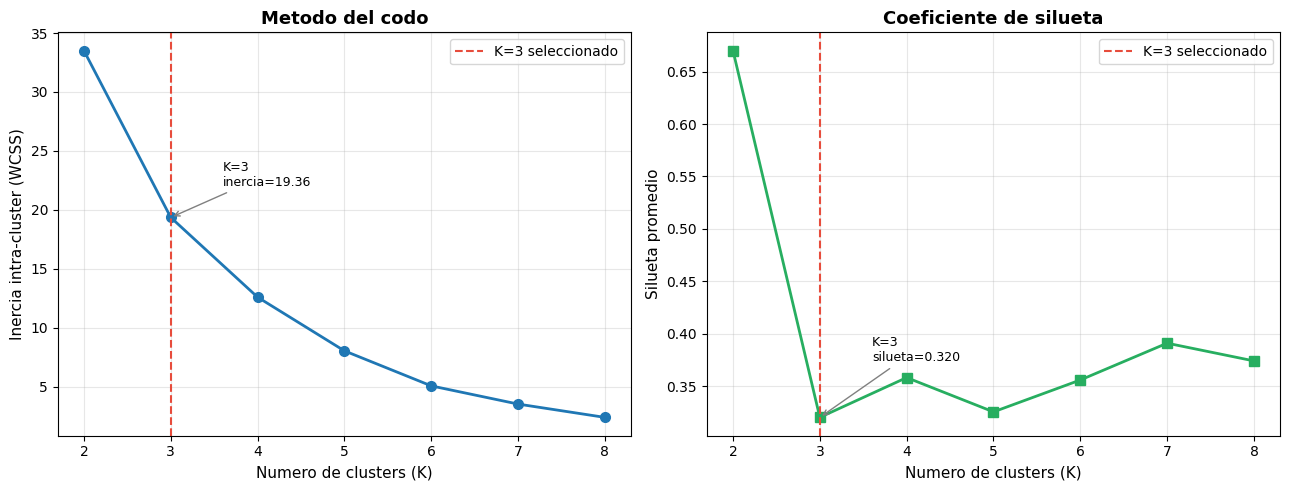

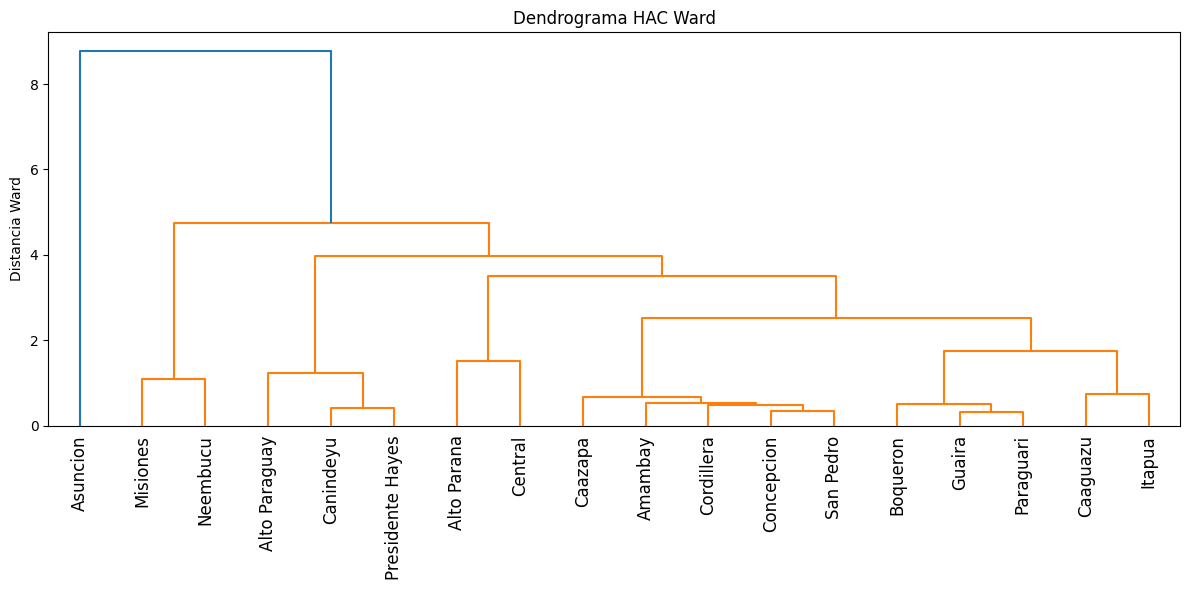


Variables utilizadas en el clustering: ['C_TOTAL', 'IC_TOTAL', 'IC_PRES', 'IC_VIRT']
Silueta K=3: 0.320
Concordancia K-means / HAC Ward: 72.2% (13/18)

TABLA 4.3. RESUMEN DE RESULTADOS POR DEPARTAMENTO. ANO BASE 2022
    Departamento  Carreras  IC (x10K)  Score Pertinencia             Prioridad
   Alto Paraguay         2       4.56              0.333      ALTA (Suboferta)
       Canindeyu       161      29.95              1.000      ALTA (Suboferta)
Presidente Hayes       113      32.75              1.000      ALTA (Suboferta)
         Central      2461      47.61              1.000      ALTA (Suboferta)
         Amambay       262      55.07              1.000      ALTA (Suboferta)
      Cordillera       434      61.14              1.000      ALTA (Suboferta)
       San Pedro       622      63.36              1.000      ALTA (Suboferta)
     Alto Parana      1352      64.89              1.000      ALTA (Suboferta)
      Concepcion       384      67.69              1.000      ALTA (Sub

In [ ]:
print("\n[6/10] Ejecutando clustering K-means y HAC Ward (4 variables)...")
general, concordancia, validacion_k = ejecutar_clustering(general)

# Generar e imprimir la Tabla 4.3 de la tesis.
tabla_4_3 = generar_tabla_4_3(general)


### Paso 7/10 — Proyectar la demanda 2023-2032 (OLS y geométrica)

Esta celda invoca `proyectar_demanda(p_hat)`, que calcula, para cada
departamento, la regresión lineal OLS y la proyección geométrica sobre el
horizonte 2023-2032, devolviendo la tabla de parámetros y proyecciones en
`proyecciones` y la tabla de comparación año a año en
`comparacion_modelos`. Al final imprime el rango de valores de R² obtenido
entre los 18 departamentos y el RMSE promedio de los ajustes.


In [ ]:
print("\n[7/10] Proyectando demanda 2023-2032...")
proyecciones, comparacion_modelos = proyectar_demanda(p_hat)
print(f"R2: {proyecciones['R2'].min():.3f} a {proyecciones['R2'].max():.3f}")
print(f"RMSE promedio: {proyecciones['RMSE'].mean():,.0f} personas")



[7/10] Proyectando demanda 2023-2032...
R2: 0.000 a 1.000
RMSE promedio: 5,504 personas


### Paso 8/10 — Análisis de sensibilidad de `p_hat`

Esta celda invoca `analizar_sensibilidad(pob_2022, oferta, p_hat)`, que
recalcula los índices de cobertura bajo los tres escenarios de `p_hat`
definidos en la Configuración y determina si cada departamento cambia de
cuartil entre escenarios, guardando el resultado en la variable
`sensibilidad`.


In [ ]:
print("\n[8/10] Ejecutando analisis de sensibilidad...")
sensibilidad = analizar_sensibilidad(pob_2022, oferta, p_hat)



[8/10] Ejecutando analisis de sensibilidad...

Q1 POR ESCENARIO DE SENSIBILIDAD
p_hat_menos_10: ALTO PARAGUAY, AMAMBAY, CANINDEYU, CENTRAL, PRESIDENTE HAYES
p_hat_base: ALTO PARAGUAY, AMAMBAY, CANINDEYU, CENTRAL, PRESIDENTE HAYES
p_hat_mas_10: ALTO PARAGUAY, AMAMBAY, CANINDEYU, CENTRAL, PRESIDENTE HAYES


### Paso 9/10 — Calcular el IPTE

Esta celda invoca `calcular_ipte(general, proyecciones)`, que combina los
tres componentes normalizados (cobertura invertida, brecha de pertinencia y
crecimiento relativo) en el Índice de Prioridad Territorial Educativa, y
actualiza el DataFrame `general` con las columnas correspondientes. A
continuación imprime la tabla resultante, ordenada por prioridad
(`RANK_IPTE`), junto con el detalle de cada componente para cada
departamento.


In [ ]:
print("\n[9/10] Calculando IPTE...")
general = calcular_ipte(general, proyecciones)
print(general[[
    "RANK_IPTE", "DPTO_NORM", "IPTE", "COBERTURA_N", "PERTINENCIA_N",
    "CRECIMIENTO_N", "IC_PRES", "SCORE_PERTINENCIA",
]].round(3).to_string(index=False))



[9/10] Calculando IPTE...
 RANK_IPTE        DPTO_NORM  IPTE  COBERTURA_N  PERTINENCIA_N  CRECIMIENTO_N  IC_PRES  SCORE_PERTINENCIA
         1    ALTO PARAGUAY 0.962        1.000          1.000          0.886    4.560              0.333
         2         BOQUERON 0.679        0.662          0.375          1.000   79.425              0.750
         3         NEEMBUCU 0.612        0.628          1.000          0.208   86.871              0.333
         4        CANINDEYU 0.595        0.885          0.000          0.901   29.950              1.000
         5 PRESIDENTE HAYES 0.580        0.873          0.000          0.867   32.746              1.000
         6          AMAMBAY 0.552        0.772          0.000          0.883   55.066              1.000
         7          CENTRAL 0.550        0.805          0.000          0.844   47.613              1.000
         8      ALTO PARANA 0.505        0.727          0.000          0.788   64.886              1.000
         9         MISIONES 

### Paso 10/10 — Generar figuras, mapas y exportar todos los CSV

Esta celda invoca, en orden, cada una de las funciones de gráficos
definidas en la sección 14 (`grafico_ic`, `grafico_ic_vs_mediana`,
`grafico_modalidades`, `grafico_clusters`, `grafico_pertinencia`,
`grafico_proyeccion_concepcion`), pasándoles el DataFrame `general` ya
completo con todos los indicadores calculados en los pasos anteriores.
Luego invoca las funciones de mapas definidas en la sección 15
(`guardar_mapa_estatico` para los tres mapas PNG de cobertura, pertinencia
y clusters; `guardar_mapa_folium` para los tres mapas HTML interactivos; y
`guardar_mapa_proyeccion_temporal` para el mapa con capa seleccionable por
año). Por último, invoca `exportar_resultados` con los diez DataFrames
producidos a lo largo del pipeline, que guarda todos los CSV finales en la
carpeta de resultados.



[10/10] Generando figuras, mapas y CSV...


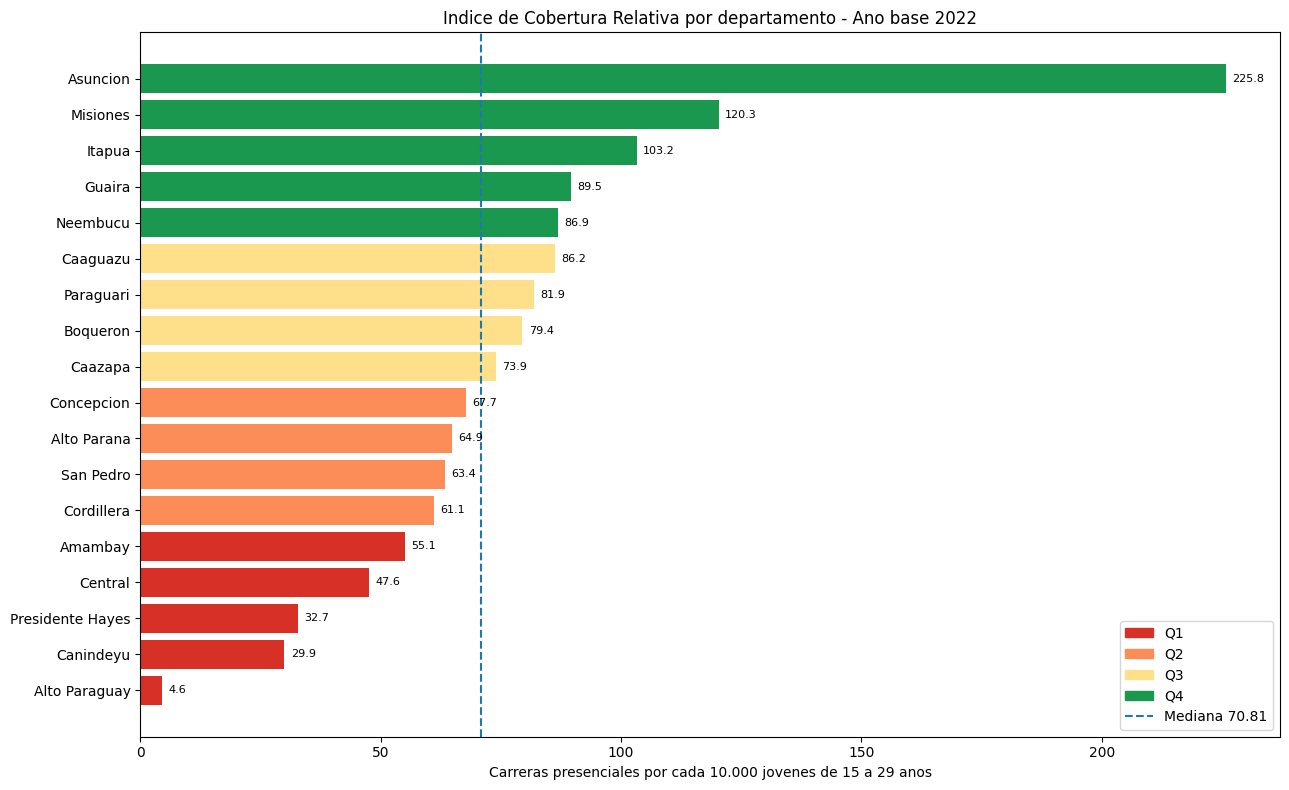

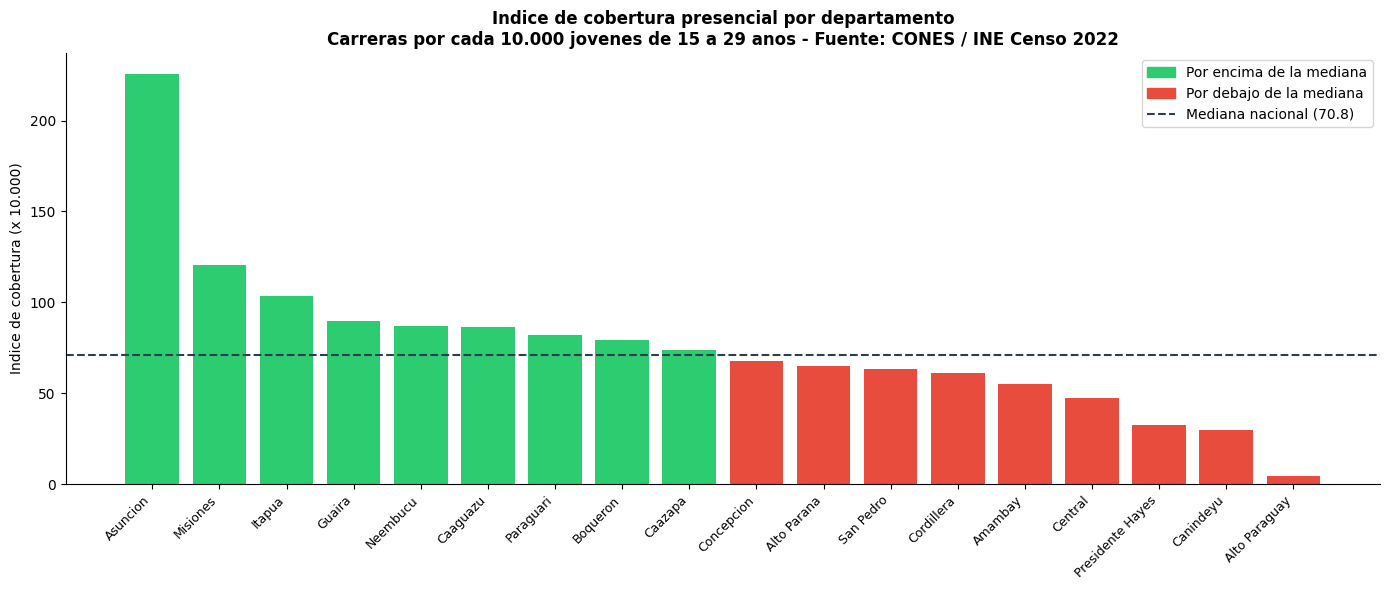

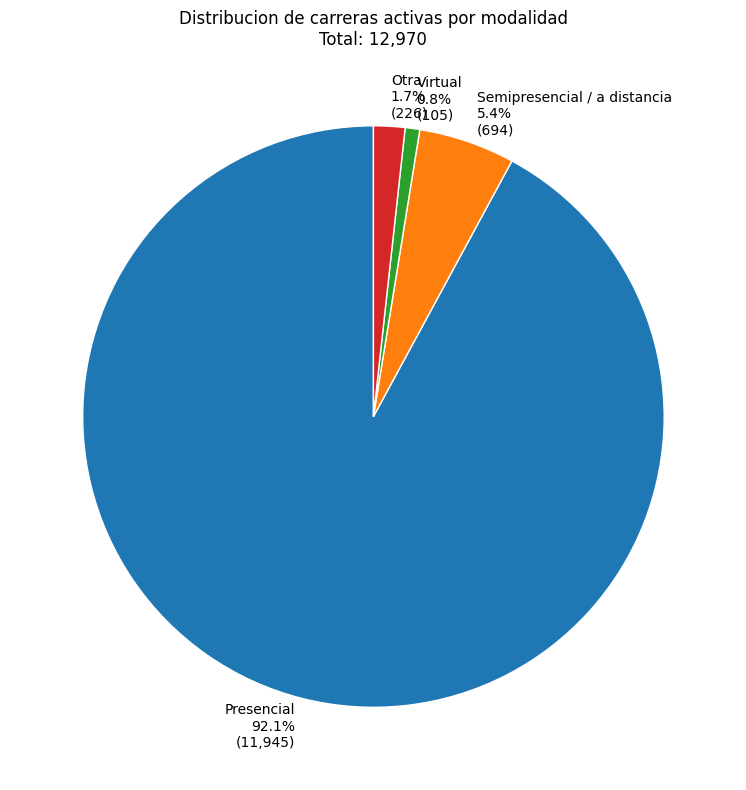

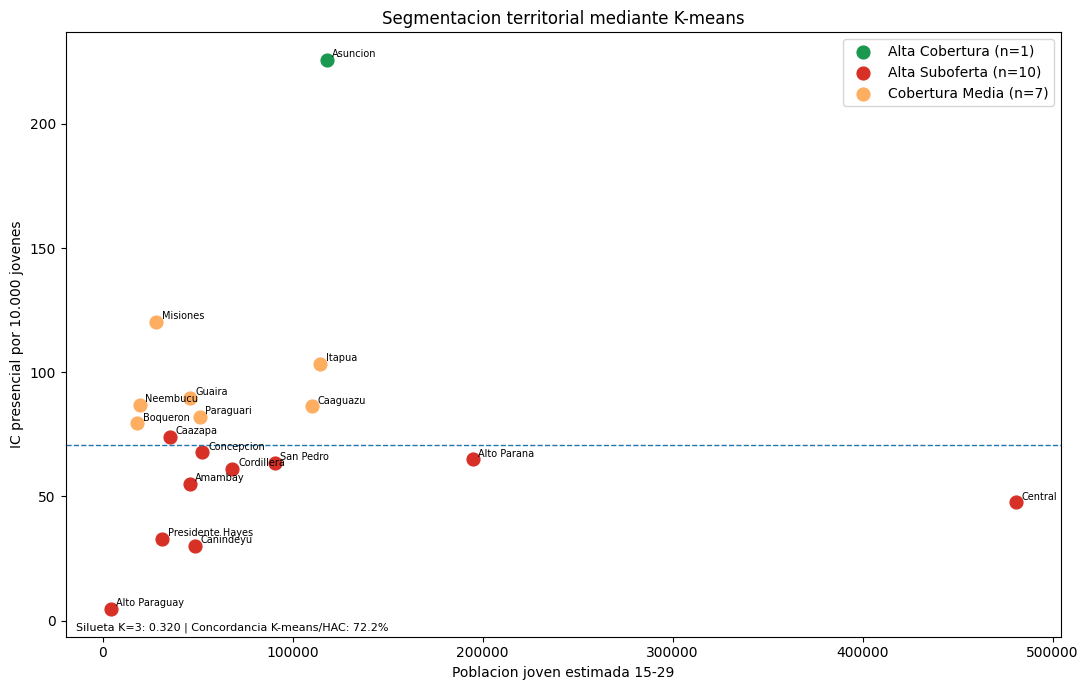

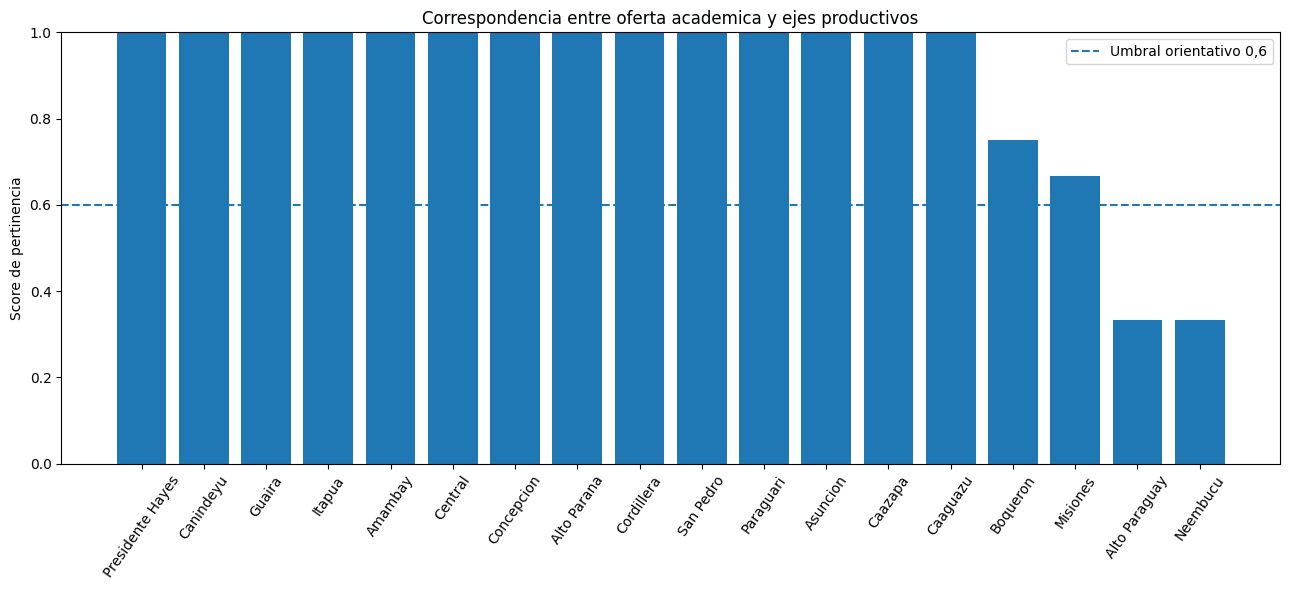

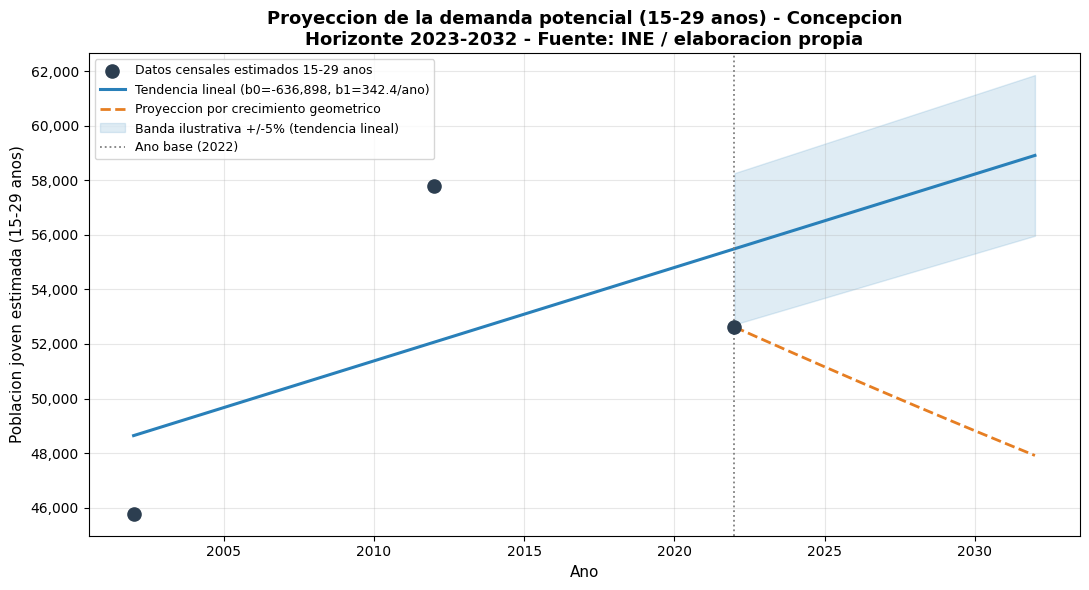

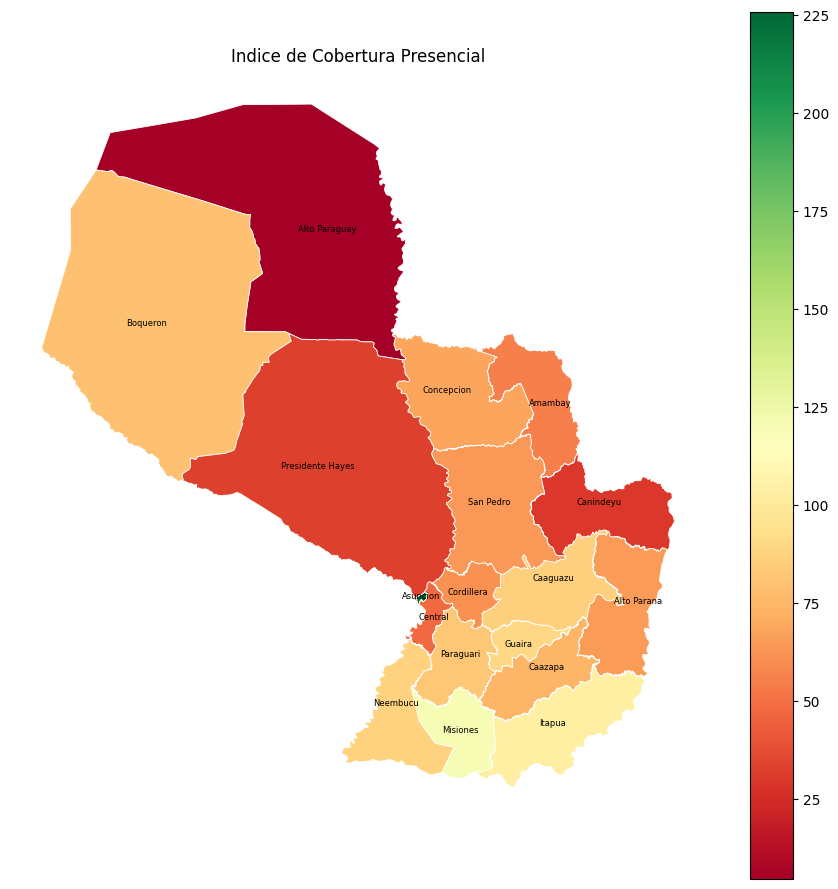

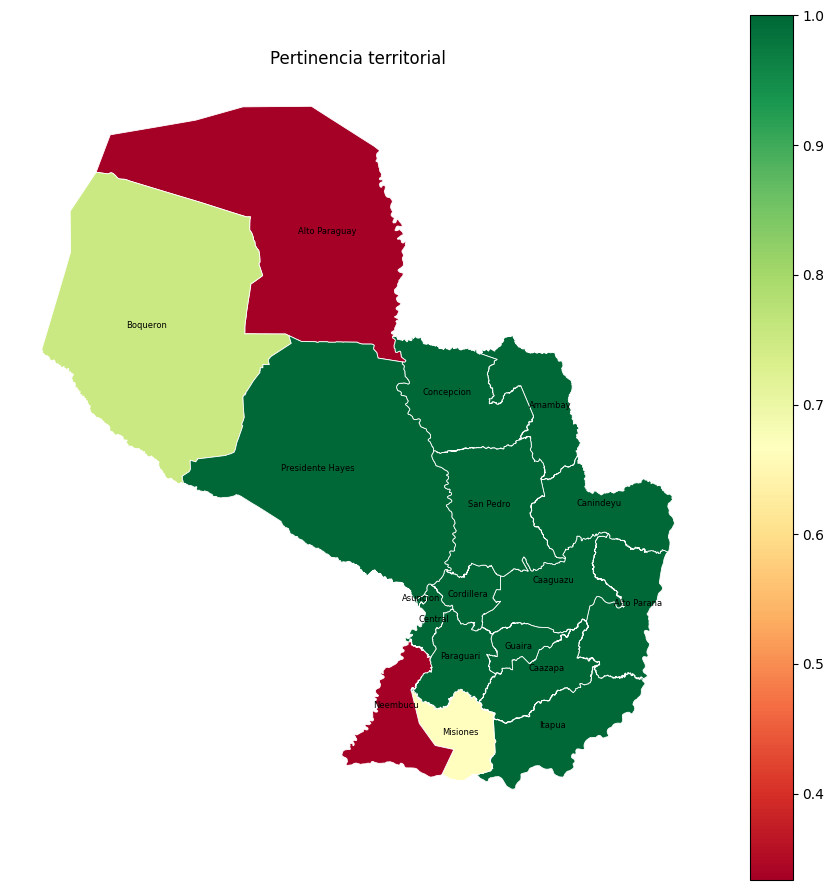

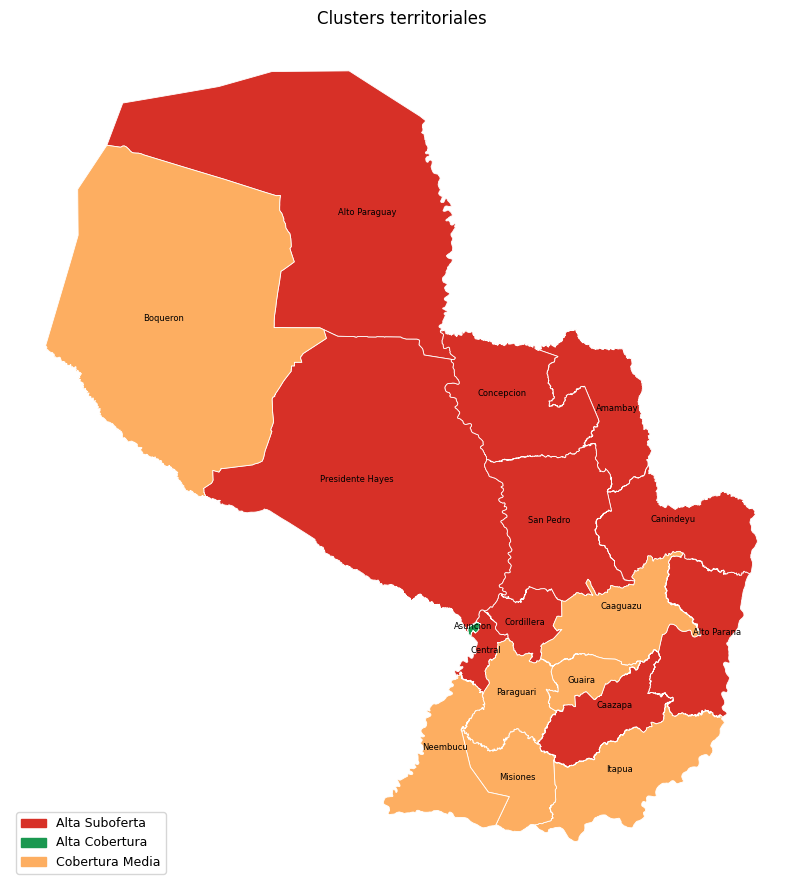

Mapa interactivo guardado en: resultados_tesis/mapas/mapa_cobertura_presencial.html
Mapa interactivo guardado en: resultados_tesis/mapas/mapa_oferta_total.html
Mapa interactivo guardado en: resultados_tesis/mapas/mapa_pertinencia.html
Mapa temporal guardado en: resultados_tesis/mapas/mapa_evolucion_demanda_2022_2032.html
Todos los CSV de resultados fueron guardados en: /content/resultados_tesis

Pipeline finalizado correctamente.
Resultados guardados en: /content/resultados_tesis


In [ ]:
print("\n[10/10] Generando figuras, mapas y CSV...")
grafico_ic(general)
grafico_ic_vs_mediana(general)
grafico_modalidades(cones)
silueta = float(concordancia["SILUETA_K3"].iloc[0])
conc_global = float(concordancia["CONCORDANCIA_GLOBAL"].iloc[0])
grafico_clusters(general, conc_global, silueta)
grafico_pertinencia(general)
grafico_proyeccion_concepcion(proyecciones)

guardar_mapa_estatico(gdf, general, "IC_PRES", "Indice de Cobertura Presencial", "fig_4_1_mapa_cobertura.png", cmap="RdYlGn")
guardar_mapa_estatico(gdf, general, "SCORE_PERTINENCIA", "Pertinencia territorial", "fig_4_3_mapa_pertinencia.png", cmap="RdYlGn")
guardar_mapa_estatico(
    gdf, general, "CLUSTER_LABEL", "Clusters territoriales", "fig_4_2_mapa_clusters.png",
    categorico=True,
    colores_categoria={
        "Alta Suboferta": "#d73027",
        "Cobertura Media": "#fdae61",
        "Alta Cobertura": "#1a9850",
    },
)

guardar_mapa_folium(gdf, general, "IC_PRES", "Cobertura presencial", "mapa_cobertura_presencial.html", fill_color="RdYlGn")
guardar_mapa_folium(gdf, general, "IC_TOTAL", "Oferta total relativa", "mapa_oferta_total.html", fill_color="YlOrRd")
guardar_mapa_folium(gdf, general, "SCORE_PERTINENCIA", "Pertinencia territorial", "mapa_pertinencia.html", fill_color="RdYlGn")
guardar_mapa_proyeccion_temporal(gdf, proyecciones)

exportar_resultados(
    general, oferta_area, proyecciones, comparacion_modelos, sensibilidad,
    concordancia, moran, pertinencia, diversidad, ranking_divergencia,
)


print("\nPipeline finalizado correctamente.")
print(f"Resultados guardados en: {CARPETA_SALIDA.resolve()}")


### (Opcional) Descargar todos los resultados como un .zip

Esta celda comprime toda la carpeta `resultados_tesis/` (CSV, figuras y
mapas) en un único archivo `.zip` usando `shutil.make_archive`, y luego lo
descarga al equipo local mediante `colab_files.download`. Es una manera de
obtener de una sola vez todo lo generado por el pipeline, sin tener que
descargar archivo por archivo desde el panel de archivos de Colab.


In [ ]:
import shutil
from google.colab import files as colab_files

nombre_zip = "resultados_tesis"
shutil.make_archive(nombre_zip, "zip", CARPETA_SALIDA)
colab_files.download(f"{nombre_zip}.zip")
